# Regressione Random Forest

Procediamo dunque con la regressione tramite Random Forest Regressor.

Questo algoritmo crea una foresta di alberi decisionali le cui foglie non corrispondono più a classi ma a valori numerici, pertanto, la predizione non corrisponde più alla classe predetta dalla maggioranza degli alberi ma alla media delle predizioni numeriche di tutti gli alberi.

In [1]:
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.regr_funcs as fs

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 58327419

# Modelli orari

Come negli altri notebook, cominciamo cercando di compiere predizioni per l'ora successiva. Questo chiaramente ha un'utilità pratica minore nella maggior parte dei casi ma ci permette di lavorare con molti più dati e, pertanto, ci aspettiamo predizioni più accurate e precise.

## PM10

In [3]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_PM10_df = pd.read_csv('../../data/processed/dataset_hour_PM10_processed.csv')
hour_PM10_df.dropna(inplace=True)

In [4]:
hour_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,precipitation,PM10_1,PM10_2,PM10_3,PM10_diff_1,PM10_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,21.0,20.0,19.0,1.0,2.0,18.0,16.969367,14.669913,19.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,21.0,20.0,-2.0,-1.0,16.0,15.329278,16.969367,24.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,24.0,19.0,21.0,5.0,3.0,16.0,17.519438,15.329278,19.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,24.0,19.0,-5.0,0.0,15.0,17.446178,17.519438,22.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,22.0,19.0,24.0,3.0,-2.0,15.0,17.484408,17.446178,26.0


### Modello

Seguiamo la stessa procedura usata molte volte in precedenza: alleniamo il modello su un insieme di train (80%) ottenendo anche i valori ottimali per gli iperparametri e, successivamente, valutiamo la performance del modello attraverso l'insieme di test (20%). Ripetiamo questo per ciascun inquinante.

In [5]:
# Time Series Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

# griglia degli iperparametri, inizialmente abbiamo operato un GridSearchCV su tutta la griglia ma dato il lungo tempo richiesto per questa operazione, 
# (più di 30 min) scegliamo di utilizzare solo la combinazione migliore per tutti gli allenamenti successivi. Riportiamo qui la griglia originale:
#param_grid_rfr = {'n_estimators': [100, 200, 500],                   # numero di alberi
#                    'max_depth': [5, 10, 20, None],                  # massima profondità degli alberi
#                    'min_samples_split': [2, 5, 10],                 # numero minimo di sample per creare una diramazione
#                    'min_samples_leaf': [1, 2, 5],                   # numero minimo di sample per foglia
#                    'max_features': [1.0, 'sqrt', 'log2'],           # numero massimo di feature considerate per uno split
#                    'bootstrap': [True, False]}                      # bootstrap


param_grid_rfr = {'n_estimators': [200],                              # numero di alberi
                    'max_depth': [5],                                 # massima profondità degli alberi
                    'min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'max_features': [1.0],                            # numero massimo di feature considerate per uno split
                    'bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM10_h = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # vogliamo minimizzare l'RMSE, quindi massimizziamo il suo opposto
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [6]:
# splittiamo il dataset
feature_cols = hour_PM10_df.columns.difference(['target'])

# creiamo train e test
PM10_h_X_train, _, PM10_h_X_test, PM10_h_y_train, _, PM10_h_y_test = fs.get_train_valid_test(hour_PM10_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [7]:
# training
rfr_PM10_h.fit(PM10_h_X_train, PM10_h_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...tate=58327419)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5], 'max_features': [1.0], 'min_samples_leaf': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [8]:
print('Best score:')
print(rfr_PM10_h.best_score_)
# miglior modello
best_rfr_PM10_h = rfr_PM10_h.best_estimator_

Best score:
-6.259306427692394


### Studio importanza features

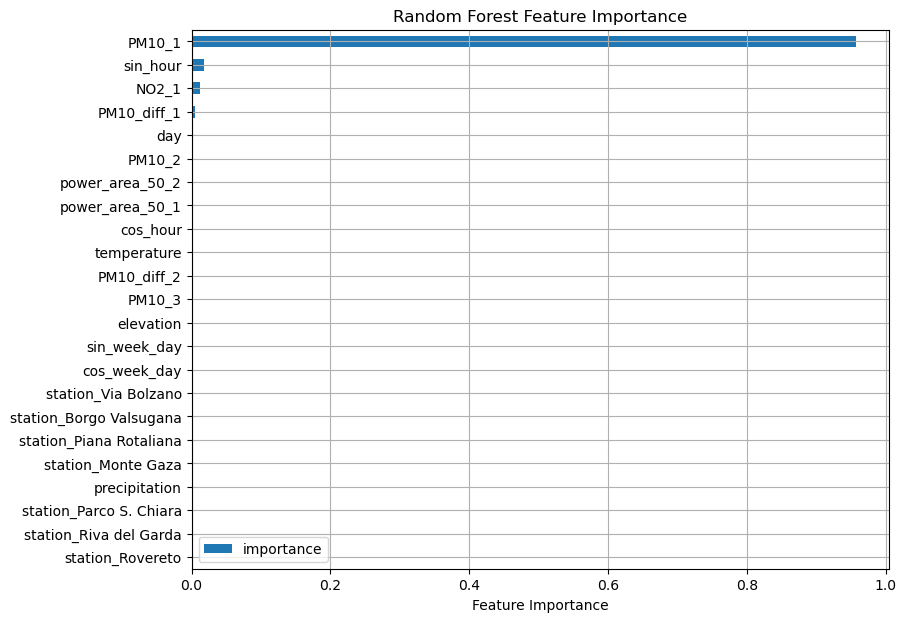

In [9]:
fs.display_importances(best_rfr_PM10_h, feature_cols)

Vediamo che la feature di gran lunga più rilevante è la concentrazione di PM10 nell'ora precedente, il che non ci stupisce essendo questa la feature più logicamente collegata al nostro target. Appare interessante che, per quanto molto meno rilevante, la seconda feature più importante sia collegata all'orario.

### Valutazione performance

In [78]:
full_PM10_h_tr = PM10_h_X_train.copy()
full_PM10_h_tr['actual'] = PM10_h_y_train
full_PM10_h_tr['prediction'] = best_rfr_PM10_h.predict(PM10_h_X_train)

full_PM10_h_te = PM10_h_X_test.copy()
full_PM10_h_te['actual'] = PM10_h_y_test
full_PM10_h_te['prediction'] = best_rfr_PM10_h.predict(PM10_h_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM10_h_tr['actual'], full_PM10_h_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM10_h_te['actual'], full_PM10_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          33.64127780148836
Root Mean Squared Error (RMSE):    5.800110154254689
Mean Absolute Error (MAE):         3.0769183908026774
Coefficient of Determination (R2): 0.9057775546964977
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          33.954642034128774
Root Mean Squared Error (RMSE):    5.8270611833177774
Mean Absolute Error (MAE):         3.7282990954871664
Coefficient of Determination (R2): 0.9383076744152915


Vediamo da questi parametri che il modello funziona relativamente bene. Il valore di $R^2$ superiore a 0.9 è solitamente indice di buone previsioni; tuttavia, poiché trattiamo dati con una importante dipendenza temporale, questo parametro (che fa riferimento alla media del campione) è meno rilevante. Scegliamo quindi di concentrarci maggiormente su RMSE e MAE. Il valore del MAE ci indica che il nostro modello commette mediamente un errore di circa 3.7 $\mu g/m^3$, che, data una deviazione standard dei dati di circa 20 $\mu g/m^3$, appare come un ottimo risultato.

### Grafici previsioni

Mostriamo graficamente il confronto tra i dati effettivi e le previsioni del nostro modello, stazione per stazione.

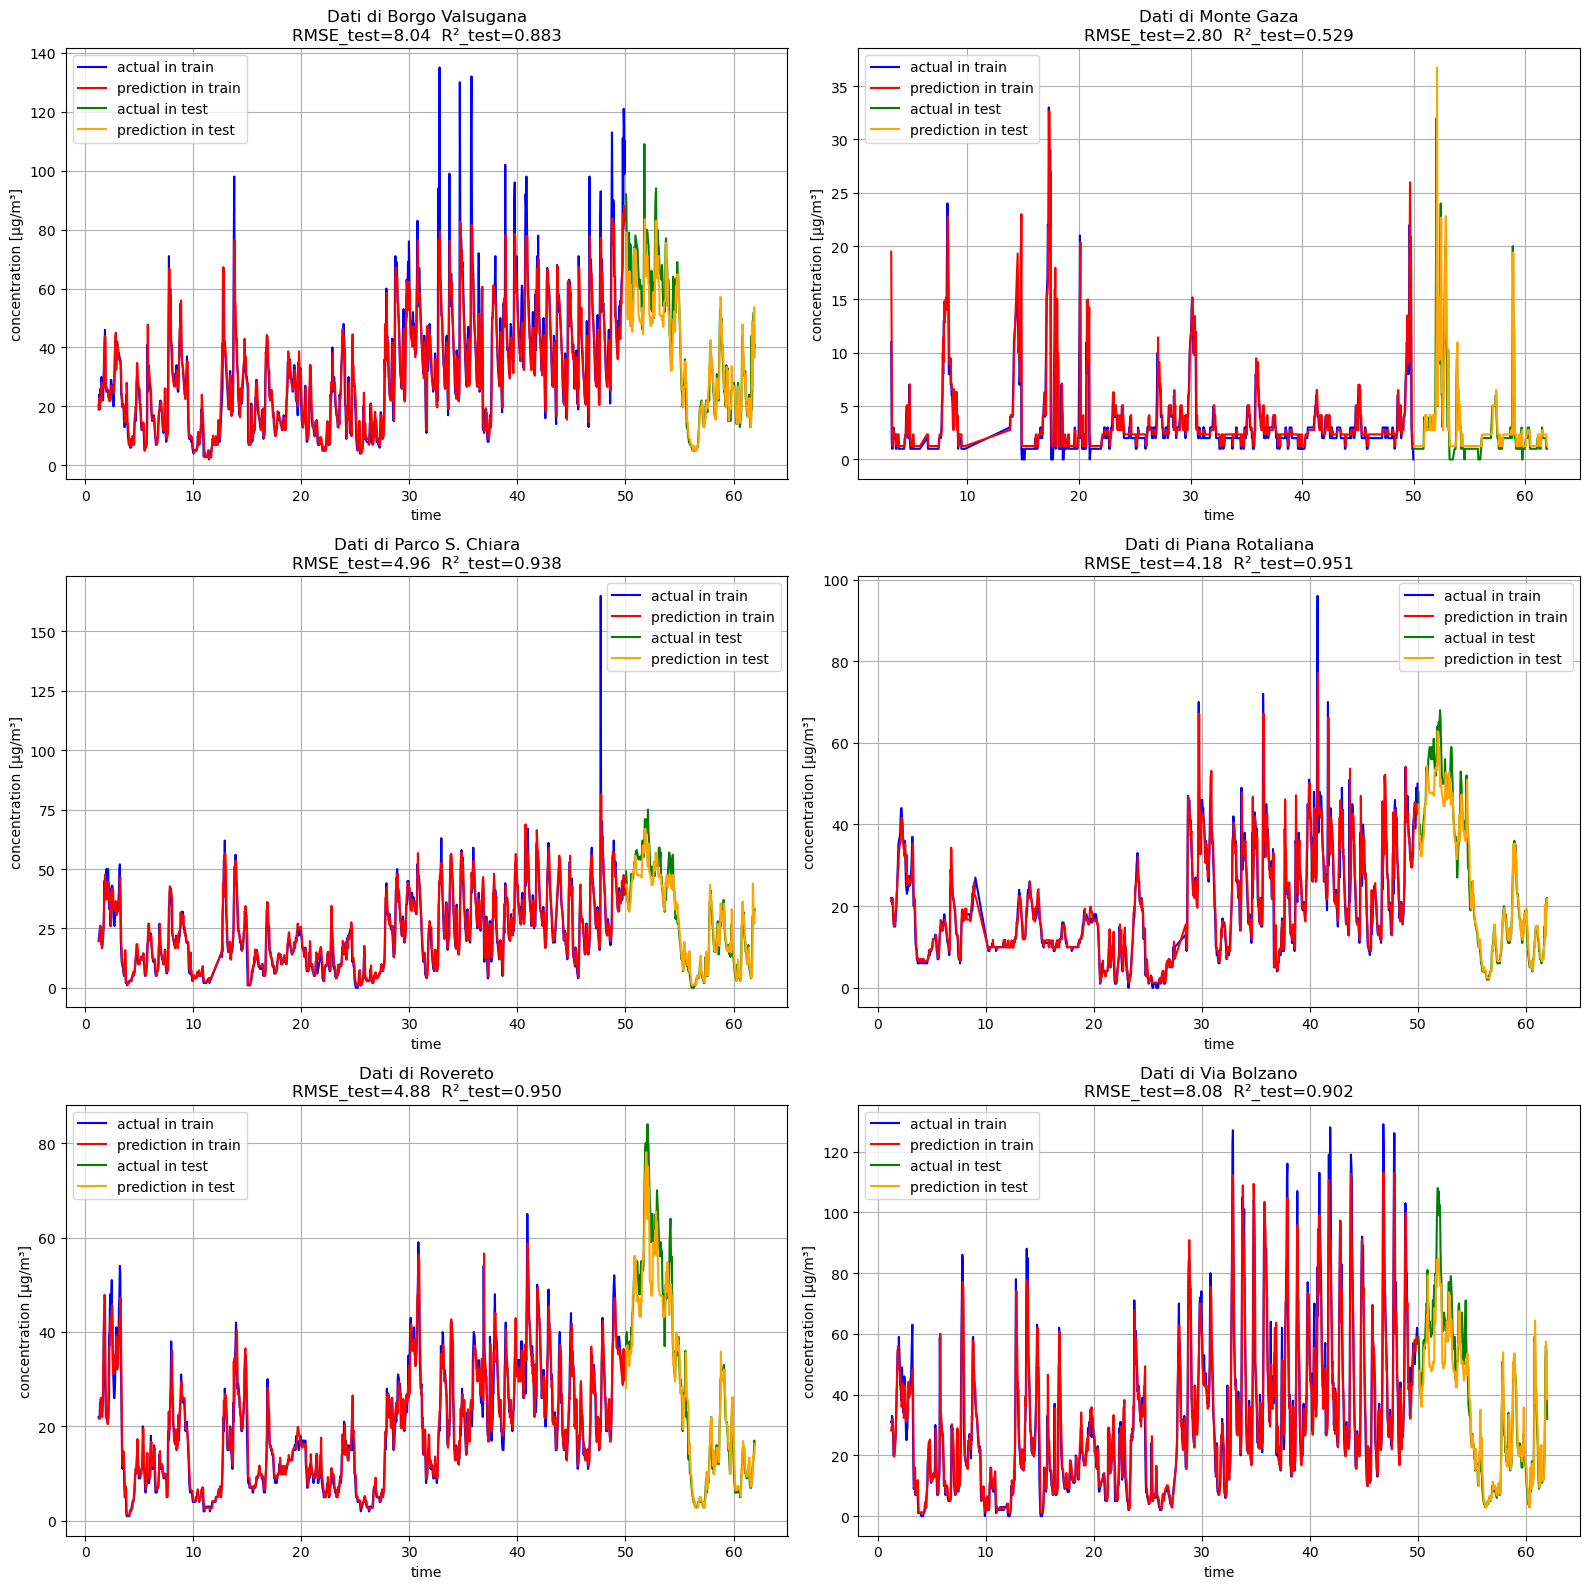

In [11]:
fs.plot_predictions(best_rfr_PM10_h, PM10_h_X_train, PM10_h_y_train, PM10_h_X_test, PM10_h_y_test)

I risultati dei grafici appaiono incoraggianti, le previsioni seguono fedelmente i punti reali. Appare chiaro tuttavia che il modello fatica particolarmente in prossimità dei marcati picchi della funzione. Inoltre, data la scala temporale del problema, è difficile che le previsioni del modello si allontanino incredibilmente dai dati reali visto il breve intervallo temporale tra dati e previsione.
In conclusione, a causa della scala, è difficile valutare correttamente il modello usando unicamente i grafici. Scegliamo quindi di confermare il giudizio positivo ottenuto a partire dai parametri indicati sopra.

## PM2.5

#### Importiamo il dataframe

In [79]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_PM25_df = pd.read_csv('../../data/processed/dataset_hour_PM2_5_processed.csv')
hour_PM25_df.dropna(inplace=True)

hour_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,precipitation,PM10_1,PM10_2,PM10_3,PM10_diff_1,PM10_diff_2,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,21.0,20.0,19.0,1.0,2.0,18.0,16.969367,14.669913,19.0
1,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,21.0,20.0,-2.0,-1.0,16.0,15.329278,16.969367,24.0
2,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,24.0,19.0,21.0,5.0,3.0,16.0,17.519438,15.329278,19.0
3,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,19.0,24.0,19.0,-5.0,0.0,15.0,17.446178,17.519438,22.0
4,1,0,0,0,0,0,0,410,1,-0.900969,...,0.0,22.0,19.0,24.0,3.0,-2.0,15.0,17.484408,17.446178,26.0


### Modello

In [14]:
param_grid_rfr = {'n_estimators': [200],                              # numero di alberi
                    'max_depth': [5],                                 # massima profondità degli alberi
                    'min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'max_features': [1.0],                            # numero massimo di feature considerate per uno split
                    'bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_PM25_h = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [15]:
# splittiamo il dataset
feature_cols = hour_PM25_df.columns.difference(['target'])

# creiamo train e test
PM25_h_X_train, _, PM25_h_X_test, PM25_h_y_train, _, PM25_h_y_test = fs.get_train_valid_test(hour_PM25_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [16]:
# training
rfr_PM25_h.fit(PM25_h_X_train, PM25_h_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...tate=58327419)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5], 'max_features': [1.0], 'min_samples_leaf': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [17]:
print('Best score:')
print(rfr_PM25_h.best_score_)
# miglior modello
best_rfr_PM25_h = rfr_PM25_h.best_estimator_

Best score:
-5.091483196796344


### Studio importanza features

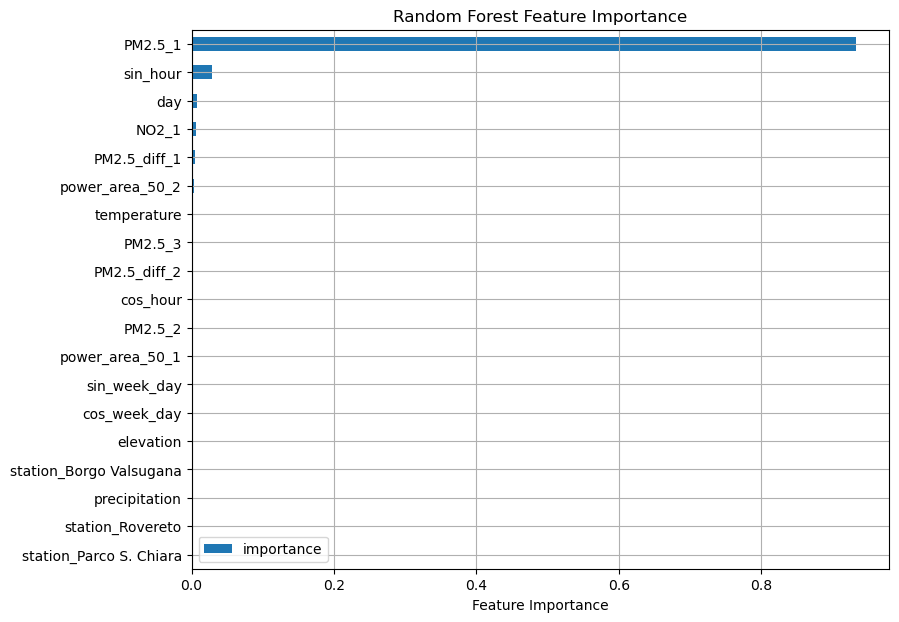

In [18]:
fs.display_importances(best_rfr_PM25_h, feature_cols)

Come prima, vediamo che il modello fa affidamento quasi unicamente alla concentrazione dell'inquinante in questione nell'ora precedente, il che non ci stupisce.

### Valutazione performance

In [19]:
full_PM25_h_tr = PM25_h_X_train.copy()
full_PM25_h_tr['actual'] = PM25_h_y_train
full_PM25_h_tr['prediction'] = best_rfr_PM25_h.predict(PM25_h_X_train)

full_PM25_h_te = PM25_h_X_test.copy()
full_PM25_h_te['actual'] = PM25_h_y_test
full_PM25_h_te['prediction'] = best_rfr_PM25_h.predict(PM25_h_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM25_h_tr['actual'], full_PM25_h_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM25_h_te['actual'], full_PM25_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          18.558892315732102
Root Mean Squared Error (RMSE):    4.308003286411479
Mean Absolute Error (MAE):         2.542400925208567
Coefficient of Determination (R2): 0.8765617650866607
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          25.172182645627245
Root Mean Squared Error (RMSE):    5.017188719355417
Mean Absolute Error (MAE):         3.5804554580918486
Coefficient of Determination (R2): 0.9170379400335368


Vediamo che il modello è buono, con parametri comparabili a quelli ottenuti precedentemente.

### Grafici previsioni

Mostriamo graficamente il confronto tra i dati effettivi e le previsioni del nostro modello, stazione per stazione.

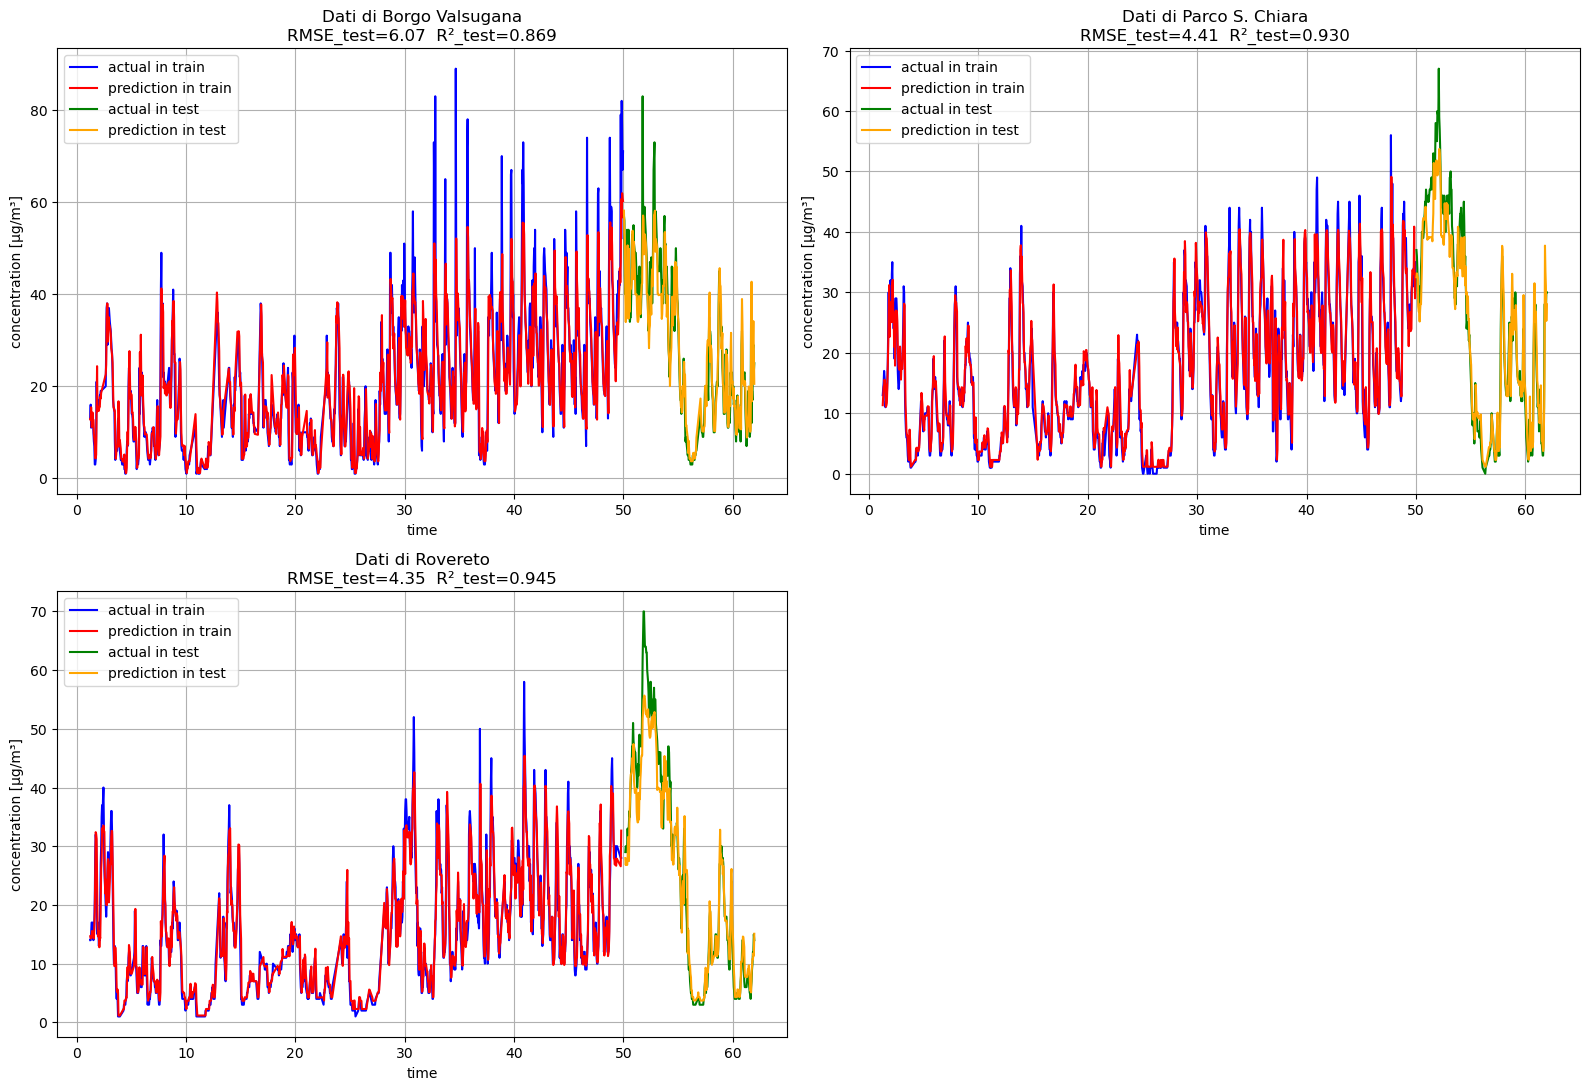

In [20]:
fs.plot_predictions(best_rfr_PM25_h, PM25_h_X_train, PM25_h_y_train, PM25_h_X_test, PM25_h_y_test)

Il PM2.5 viene raccolto in meno stazioni, perciò abbiamo meno grafici. In ogni caso, vediamo un comportamento simile a quello visto prima, con previsioni piuttosto buone e un'evidente fatica del modello nelle predizioni dei picchi. Questo è particolarmente vero nell'insieme di test dove, per le stazioni di Parco S. Chiara e Rovereto, la concentrazione di PM2.5 raggiunge un picco assoluto che il modello non riesce a prevedere poiché è la prima volta che si interfaccia con dati di quella scala. Questa è una caratteristica insita nei nostri dati e, pertanto, non è possibile risolverla senza espandere il dataset aggiungendo dati che purtroppo non possediamo. In ogni caso, ci affidiamo ai valori del RMSE e del MAE per confermare la bontà del modello.

## O3

### Importiamo il dataset

In [80]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
hour_O3_df = pd.read_csv('../../data/processed/dataset_hour_O3_processed.csv')
hour_O3_df.dropna(inplace=True)

hour_O3_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,elevation,day,cos_week_day,sin_week_day,...,O3_1,O3_2,O3_3,O3_diff_1,O3_diff_2,PM10_1,NO2_1,power_area_50_1,power_area_50_2,target
0,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,2.0,2.0,2.0,0.0,0.0,21.0,18.0,16.969367,14.669913,2.0
1,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,2.0,2.0,2.0,0.0,0.0,19.0,16.0,15.329278,16.969367,2.0
2,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,2.0,2.0,2.0,0.0,0.0,24.0,16.0,17.519438,15.329278,2.0
3,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,2.0,2.0,2.0,0.0,0.0,19.0,15.0,17.446178,17.519438,3.0
4,1,0,0,0,0,0,410,1,-0.900969,-0.433884,...,3.0,2.0,2.0,1.0,1.0,22.0,15.0,17.484408,17.446178,5.0


### Modello

In [23]:
param_grid_rfr = {'n_estimators': [200],                              # numero di alberi
                    'max_depth': [5],                                 # massima profondità degli alberi
                    'min_samples_split': [2],                         # numero minimo di sample per creare una diramazione
                    'min_samples_leaf': [5],                          # numero minimo di sample per foglia
                    'max_features': [1.0],                            # numero massimo di feature considerate per uno split
                    'bootstrap': [True]}                              # bootstrap

# ricerca degli iperparametri
rfr_O3_h = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [24]:
# splittiamo il dataset
feature_cols = hour_O3_df.columns.difference(['target'])

# creiamo train e test
O3_h_X_train, _, O3_h_X_test, O3_h_y_train, _, O3_h_y_test = fs.get_train_valid_test(hour_O3_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [25]:
# training
rfr_O3_h.fit(O3_h_X_train, O3_h_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...tate=58327419)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5], 'max_features': [1.0], 'min_samples_leaf': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [26]:
print('Best score:')
print(rfr_O3_h.best_score_)
# miglior modello
best_rfr_O3_h = rfr_O3_h.best_estimator_

Best score:
-5.906782088564966


### Studio importanza features

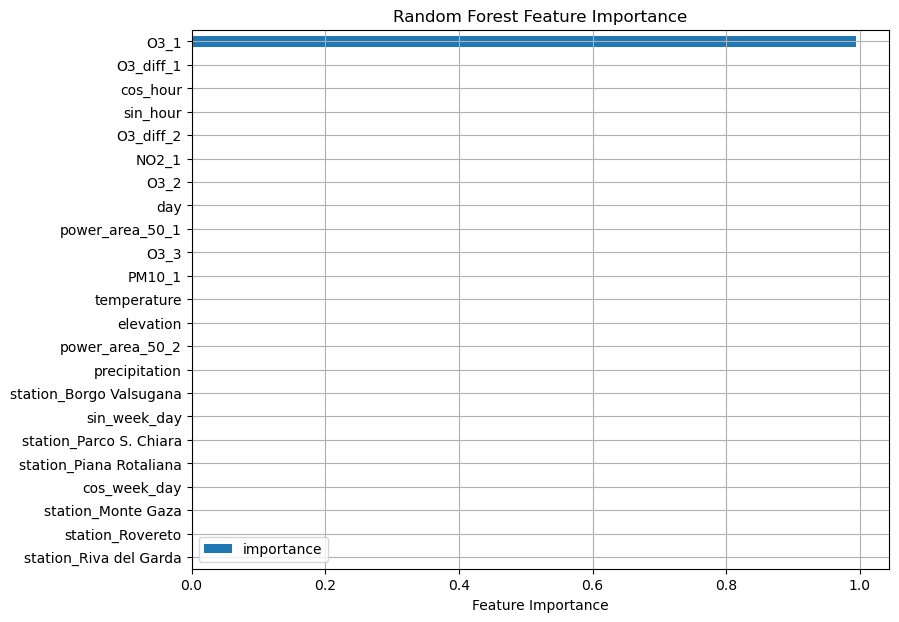

In [27]:
fs.display_importances(best_rfr_O3_h, feature_cols)

La tendenza precedente si ripropone ancora più marcatamente, con la concentrazione di ozono nell'ora precedente che determina essenzialmente la totalità delle decisioni del modello.

### Valutazione performance

In [28]:
full_O3_h_tr = O3_h_X_train.copy()
full_O3_h_tr['actual'] = O3_h_y_train
full_O3_h_tr['prediction'] = best_rfr_O3_h.predict(O3_h_X_train)

full_O3_h_te = O3_h_X_test.copy()
full_O3_h_te['actual'] = O3_h_y_test
full_O3_h_te['prediction'] = best_rfr_O3_h.predict(O3_h_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_O3_h_tr['actual'], full_O3_h_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_O3_h_te['actual'], full_O3_h_te['prediction'])

Performance su train
Mean Squared Error (MSE):          20.988190923248087
Root Mean Squared Error (RMSE):    4.5812870378582575
Mean Absolute Error (MAE):         2.723190722561252
Coefficient of Determination (R2): 0.9749961439326059
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          14.440921279694901
Root Mean Squared Error (RMSE):    3.8001212190790574
Mean Absolute Error (MAE):         2.197161226694909
Coefficient of Determination (R2): 0.9833185958162767


In questo caso il modello appare particolarmente buono, anche quando comparato con i modelli ottenuti per gli inquinanti precedenti.

### Grafici previsioni

Mostriamo graficamente il confronto tra i dati effettivi e le previsioni del nostro modello, stazione per stazione.

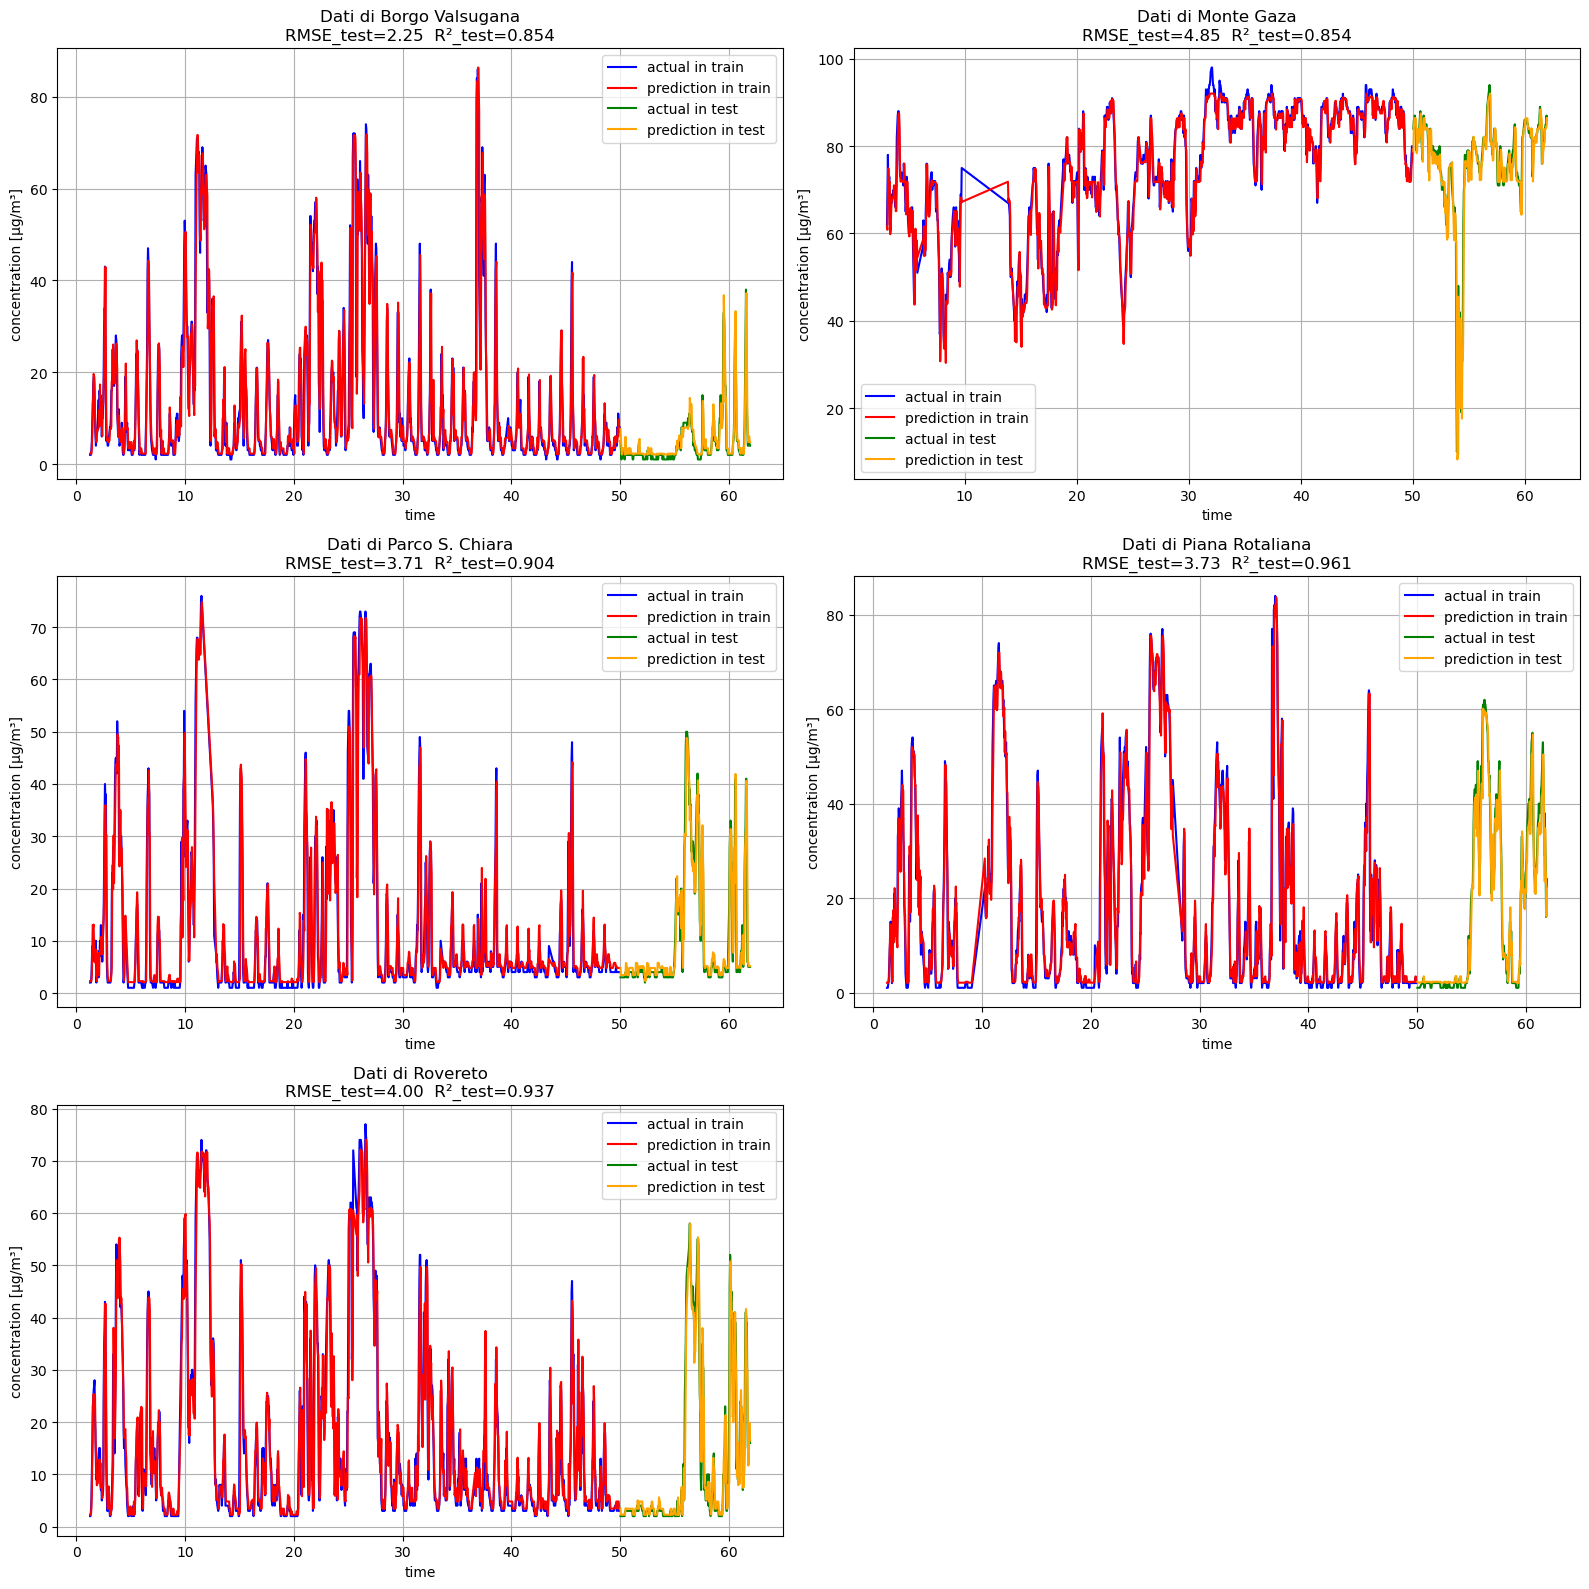

In [29]:
fs.plot_predictions(best_rfr_O3_h, O3_h_X_train, O3_h_y_train, O3_h_X_test, O3_h_y_test)

I grafici appaiono confermare la precedente buona valutazione del modello; infatti, i dati presentano picchi meno improvvisi e notiamo che il modello riesce a prevederli più fedelmente rispetto a prima. Consideriamo pertanto questo esercizio come particolarmente riuscito.

# Modelli giornalieri

Ripetiamo ora quanto fatto nella prima parte di questo notebook ma con previsioni su base giornaliera invece che oraria. Come spiegato in notebook precedenti, questo aumenta considerevolmente la difficoltà dell'esercizio poiché riduce drasticamente il numero di dati e aumenta la distanza temporale tra dati e previsione. Per questi motivi, ci aspettiamo risultati peggiori rispetto a quelli ottenuti per i modelli orari.

## PM10

In [30]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM10_df = pd.read_csv('../../data/processed/dataset_day_PM10_processed.csv')

day_PM10_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,PM10_1,PM10_2,PM10_diff_1,NO2_1,power_area_50_1,target
0,1,0,0,0,0,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,28.869565,25.739130,3.130435,21.086957,18.197335,23.652174
1,1,0,0,0,0,0,0,410,4,1.000000,0.000000,10.796739,0.126087,23.652174,28.869565,-5.217391,18.826087,17.478475,14.739130
2,1,0,0,0,0,0,0,410,5,0.623490,0.781831,7.609783,0.028261,14.739130,23.652174,-8.913043,26.739130,37.200400,17.000000
3,1,0,0,0,0,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,17.000000,14.739130,2.260870,25.913043,37.421266,14.739130
4,1,0,0,0,0,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,14.739130,17.000000,-2.260870,26.956522,35.957377,26.086957


### Modello

In [31]:
# usiamo sempre la stessa matrice di iperparametri vista precedentemente, quindi la omettiamo d'ora in avanti per una questione di sintesi
rfr_PM10_d = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [32]:
# splittiamo il dataset
feature_cols = day_PM10_df.columns.difference(['target'])

# creiamo train e test
PM10_d_X_train, _, PM10_d_X_test, PM10_d_y_train, _, PM10_d_y_test = fs.get_train_valid_test(day_PM10_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [33]:
# training
rfr_PM10_d.fit(PM10_d_X_train, PM10_d_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...tate=58327419)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5], 'max_features': [1.0], 'min_samples_leaf': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [34]:
print('Best score:')
print(rfr_PM10_d.best_score_)
# miglior modello
best_rfr_PM10_d = rfr_PM10_d.best_estimator_

Best score:
-12.091577319841955


### Studio importanza features

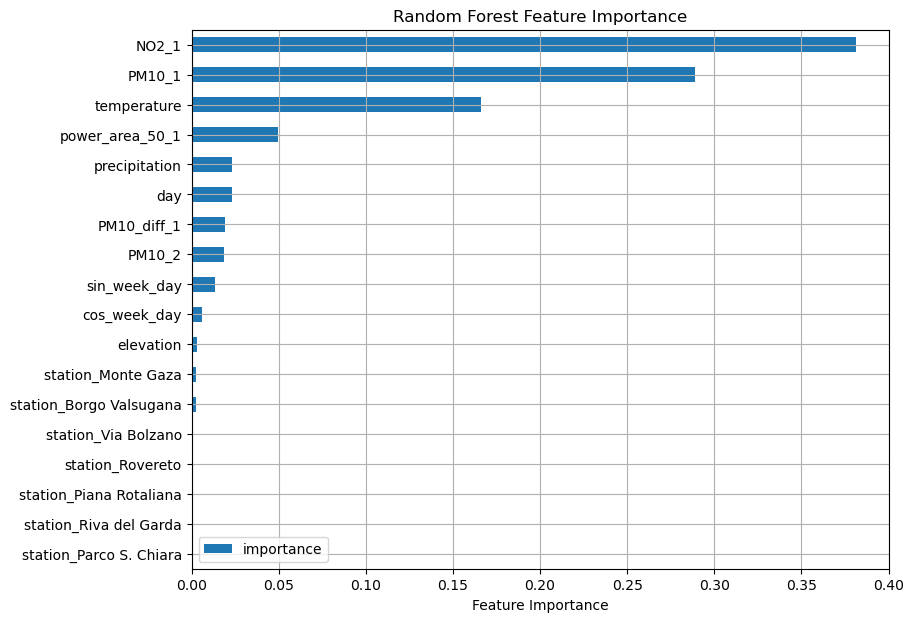

In [35]:
fs.display_importances(best_rfr_PM10_d, feature_cols)

Vediamo una distribuzione più variegata rispetto ai modelli orari trovati sopra e notiamo che la feature relativa alla concentrazione di PM10 del giorno precedente non è più la più importante poiché viene superata dalla concentrazione di NO2 del giorno precedente. In realtà ricordiamo che, come mostrato nell'EDA, i valori di questi inquinanti sono fortemente correlati e quindi ha senso che vengano usati entrambi; tuttavia, rimane importante notare come il modello prenda in considerazione molte altre feature. Questo ci suggerisce che il valore della concentrazione di un inquinante per un certo giorno sia molto meno correlato al suo valore il giorno prima rispetto a quanto sono correlate tra loro le concentrazioni di inquinanti riferite a due ore consecutive. Per questo motivo, il modello ha bisogno di fare affidamento su un ventaglio di feature più ampio e tiene conto anche di grandezze che ci sembrano intuitivamente meno importanti. È quindi possibile che stiamo sperimentando overfitting.

### Valutazione performance

In [76]:
print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(PM10_d_y_train, best_rfr_PM10_d.predict(PM10_d_X_train))
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(PM10_d_y_test, best_rfr_PM10_d.predict(PM10_d_X_test))

Performance su train
Mean Squared Error (MSE):          26.78347861622361
Root Mean Squared Error (RMSE):    5.175275704368185
Mean Absolute Error (MAE):         3.8707280825218744
Coefficient of Determination (R2): 0.883018591219585
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          205.86594530231432
Root Mean Squared Error (RMSE):    14.348029317725635
Mean Absolute Error (MAE):         9.766706539539978
Coefficient of Determination (R2): 0.5598946221499137


Vediamo che il modello funziona decisamente peggio rispetto a quanto visto per il modello orario sotto tutti i punti di vista. Assistiamo inoltre ad una drastica riduzione della qualità del modello quando applicato a test. Questo è potenzialmente legato ad un problema di overfitting ma riteniamo che, in realtà, sia dovuto ad altre caratteristiche del nostro dataset. La ridotta quantità di dati e la marcata differenza nella distribuzione dei dati tra train e test sono entrambi fattori che determinano quasi inevitabilmente una perdita di accuratezza per il nostro modello.

Confrontando questi risultati con quelli ottenuti in precedenza con il semplice algoritmo LinearRegression, notiamo che, se da un lato la random forest è più accurata nell'insieme di train, è altrettanto vero che produce risultati peggiori su test. Questo potrebbe essere un'indicazione di un leggero overfitting da parte di questo secondo modello. Equivalentemente la differenza di performance, visto il suo valore minimo, potrebbe essere dovuta ad una semplice fluttuazione statistica.

### Grafici previsioni

In questo caso, avendo molti meno dati, scegliamo di rappresentare i singoli punti in modo da poter confrontare accuratamente dati e previsioni.

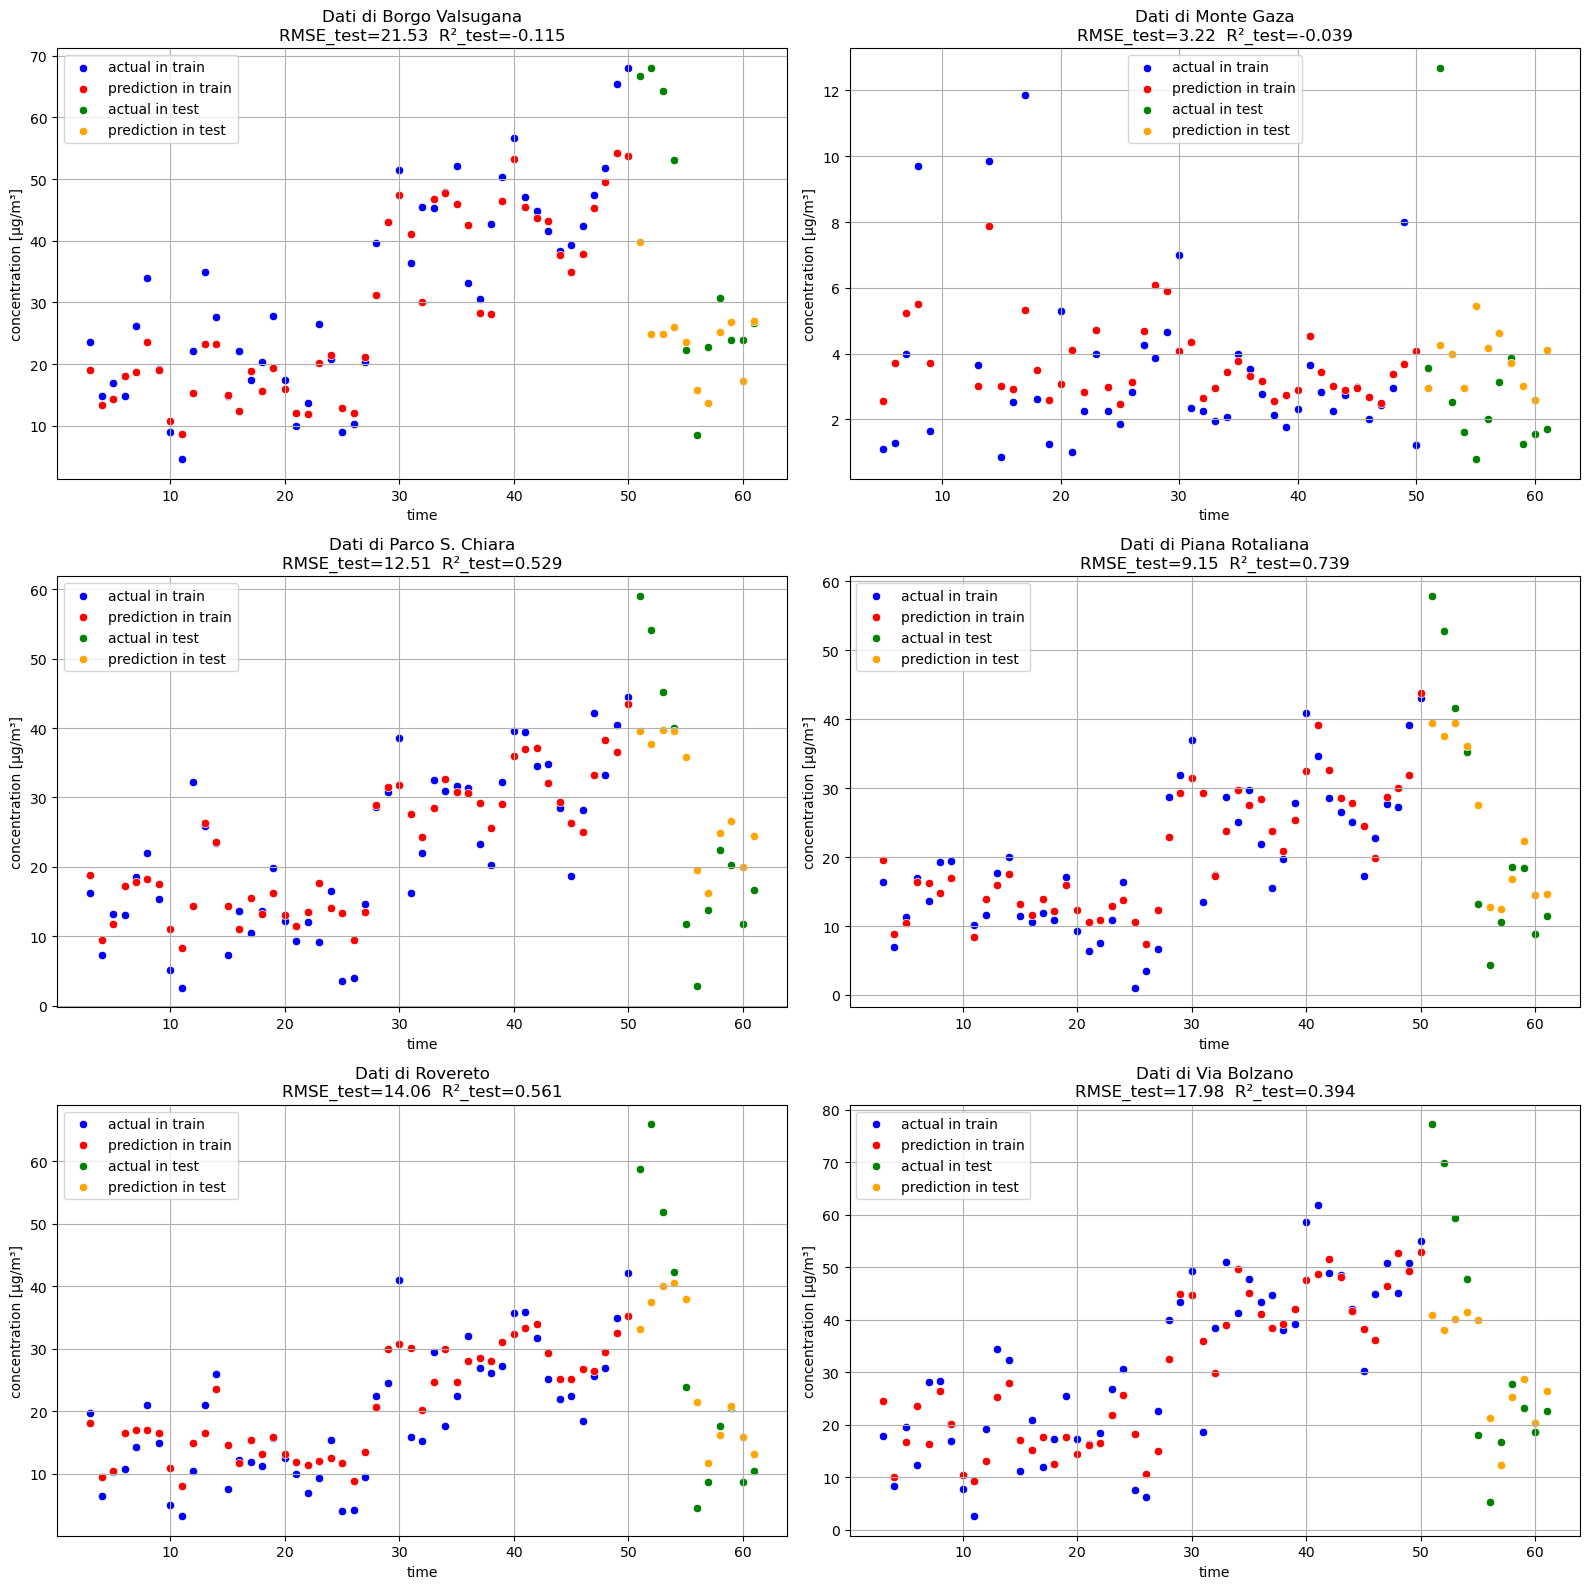

In [37]:
fs.plot_prediction_points(best_rfr_PM10_d, PM10_d_X_train, PM10_d_y_train, PM10_d_X_test, PM10_d_y_test)

Vediamo che il modello ha prestazioni decenti nell'insieme di allenamento, almeno per la maggior parte delle stazioni, ma in test performa decisamente peggio, soprattutto in corrispondenza al grande picco di inquinanti dovuto al periodo natalizio. Come spiegato sopra, il modello si interfaccia con dati di questa magnitudo solo in test e quindi non ha basi per poterli prevedere accuratamente. Questo problema non è risolvibile senza incrementare il numero di dati e, perciò, per il momento dobbiamo accontentarci dei risultati poco incoraggianti. In seguito ripeteremo l'allenamento con metodo XGBoost per verificare se un modello più sofisticato sia in grado di migliorare la performance del modello in test.

## PM2.5

In [38]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM25_df = pd.read_csv('../../data/processed/dataset_day_PM2_5_processed.csv')
day_PM25_df.dropna(inplace=True)

day_PM25_df.head()

,station_Borgo Valsugana,station_Parco S. Chiara,station_Rovereto,elevation,day,cos_week_day,sin_week_day,temperature,precipitation,PM2.5_1,PM2.5_2,PM2.5_diff_1,NO2_1,power_area_50_1,target
0,1,0,0,410,3,0.623490,-0.781831,11.231522,0.013043,24.764706,11.391304,13.373402,21.086957,18.197335,15.739130
1,1,0,0,410,4,1.000000,0.000000,10.796739,0.126087,15.739130,24.764706,-9.025575,18.826087,17.478475,8.347826
2,1,0,0,410,5,0.623490,0.781831,7.609783,0.028261,8.347826,15.739130,-7.391304,26.739130,37.200400,11.565217
3,1,0,0,410,6,-0.222521,0.974928,9.641304,0.000000,11.565217,8.347826,3.217391,25.913043,37.421266,8.260870
4,1,0,0,410,7,-0.900969,0.433884,9.980435,0.000000,8.260870,11.565217,-3.304348,26.956522,35.957377,16.478261


### Modello

In [39]:
rfr_PM25_d = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [40]:
# splittiamo il dataset
feature_cols = day_PM25_df.columns.difference(['target'])

# creiamo train e test
PM25_d_X_train, _, PM25_d_X_test, PM25_d_y_train, _, PM25_d_y_test = fs.get_train_valid_test(day_PM25_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [41]:
# training
rfr_PM25_d.fit(PM25_d_X_train, PM25_d_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...tate=58327419)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5], 'max_features': [1.0], 'min_samples_leaf': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [42]:
print('Best score:')
print(rfr_PM25_d.best_score_)
# miglior modello
best_rfr_PM25_d = rfr_PM25_d.best_estimator_

Best score:
-8.001679022496736


### Studio importanza features

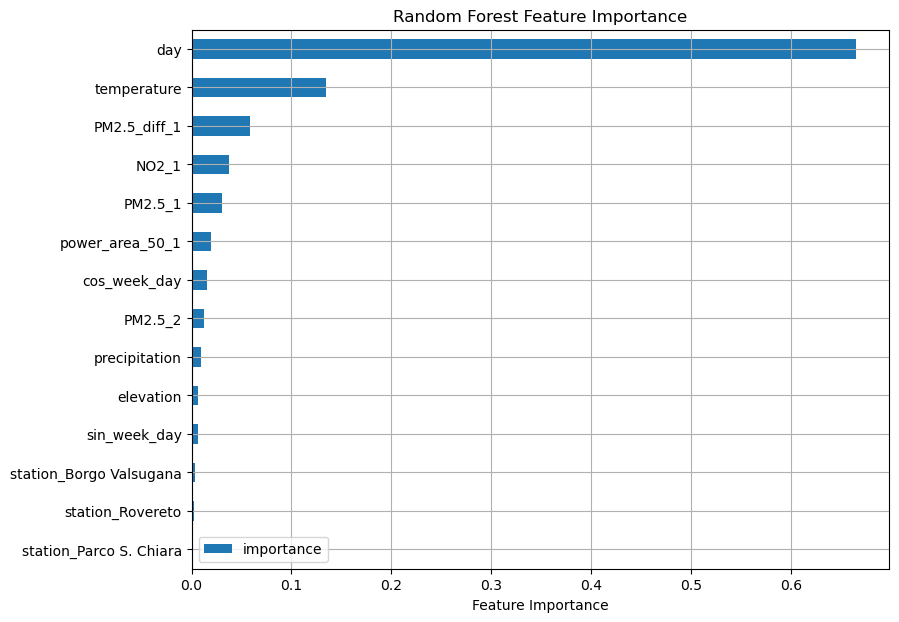

In [43]:
fs.display_importances(best_rfr_PM25_d, feature_cols)

Notiamo che rispetto a prima il modello usa una grande varietà di feature e che le prime sono poco intuitivamente collegate al valore di PM2.5 nell'aria. Questo è leggermente preoccupante poiché induce il dubbio che il modello stia essenzialmente imparando rumore.

### Valutazione performance

In [44]:
full_PM25_d_tr = PM25_d_X_train.copy()
full_PM25_d_tr['actual'] = PM25_d_y_train
full_PM25_d_tr['prediction'] = best_rfr_PM25_d.predict(PM25_d_X_train)

full_PM25_d_te = PM25_d_X_test.copy()
full_PM25_d_te['actual'] = PM25_d_y_test
full_PM25_d_te['prediction'] = best_rfr_PM25_d.predict(PM25_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM25_d_tr['actual'], full_PM25_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM25_d_te['actual'], full_PM25_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          11.73377145000314
Root Mean Squared Error (RMSE):    3.4254593049696473
Mean Absolute Error (MAE):         2.662341468274092
Coefficient of Determination (R2): 0.8711845543080254
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          222.1067640354675
Root Mean Squared Error (RMSE):    14.903246761543858
Mean Absolute Error (MAE):         12.690921593202749
Coefficient of Determination (R2): 0.152904857506032


Notiamo un importantissimo peggioramento del modello nell'interfacciarsi con dati nuovi, questo porta a pensare che stiamo quasi sicuramente commettendo overfitting. Anche se non riportato qui, abbiamo provato a rimuovere dall'allenamento le feature più importanti ('day' e 'temperature') e, sebbene la performance del modello migliori leggermente, rimane presente il drastico calo di prestazioni del modello in test. Probabilmente con questi dati non è possibile prevedere accuratamente il comportamento della qualità dell'aria, almeno non con RandomForestRegressor.

### Grafici previsioni

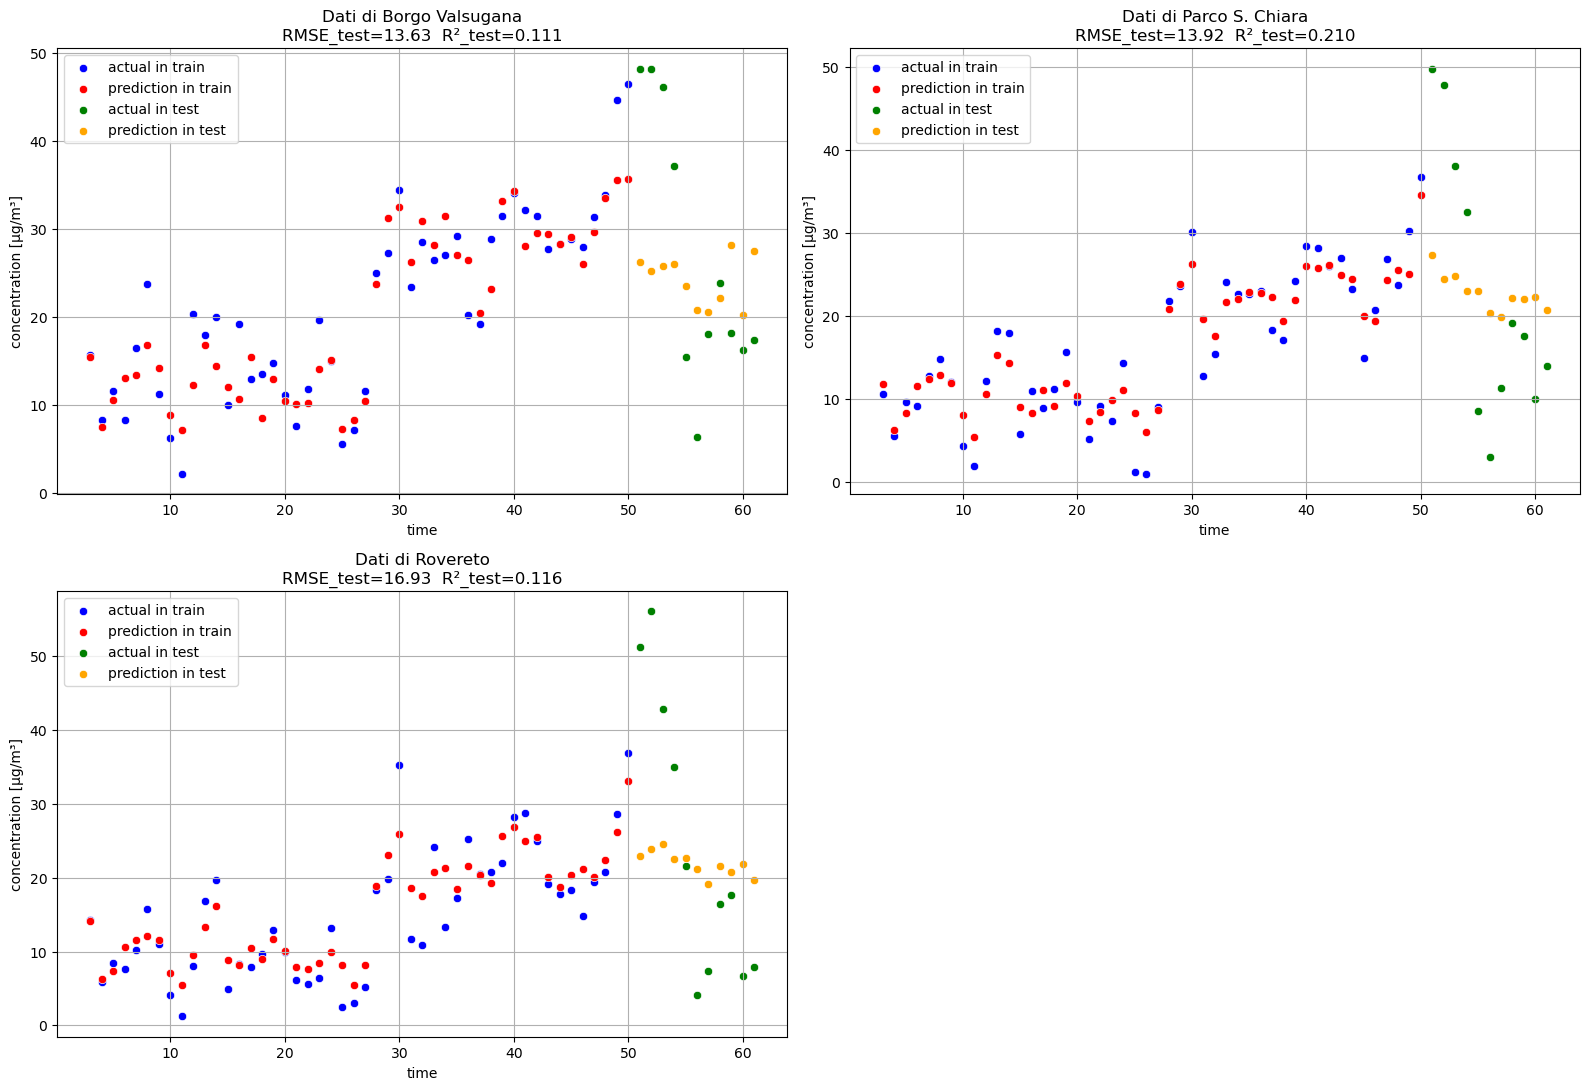

In [45]:
fs.plot_prediction_points(best_rfr_PM25_d, PM25_d_X_train, PM25_d_y_train, PM25_d_X_test, PM25_d_y_test)

I grafici confermano la bassa qualità del modello in test, mostrando come il modello non sia in grado di prevedere la rapidissima decrescita della concentrazione di PM2.5. Le previsioni del modello in test rimangono essenzialmente costanti invece che seguire l'andamento dei dati. Questo è un problema difficile da risolvere purtroppo poiché abbiamo a disposizione pochi dati e le popolazioni in train e test sono molto differenti tra loro.

## O3

In [46]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_O3_df = pd.read_csv('../../data/processed/dataset_day_O3_processed.csv')

### Modello

In [47]:
rfr_O3_d = GridSearchCV(estimator=RandomForestRegressor(random_state=seed),
                        param_grid=param_grid_rfr,                                  # cerchiamo gli iperparametri migliori
                        scoring='neg_root_mean_squared_error',                      # -RMSE
                        cv=tscv,                                                    # come spiegato nel notebook 04, dobbiamo fare la CV in ordine cronologico
                        n_jobs=-1,                                                  # usiamo la massima potenza disponibile nella CPU
                        refit=True)                                                 # vogliamo poi allenare il modello con i migliori iperparametri

### Train, Test split

In [48]:
# splittiamo il dataset
feature_cols = day_O3_df.columns.difference(['target'])

# creiamo train e test
O3_d_X_train, _, O3_d_X_test, O3_d_y_train, _, O3_d_y_test = fs.get_train_valid_test(day_O3_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [49]:
# training
rfr_O3_d.fit(O3_d_X_train, O3_d_y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...tate=58327419)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [5], 'max_features': [1.0], 'min_samples_leaf': [5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for 

In [50]:
print('Best score:')
print(rfr_O3_d.best_score_)
# miglior modello
best_rfr_O3_d = rfr_O3_d.best_estimator_

Best score:
-20.308996719403716


### Studio importanza features

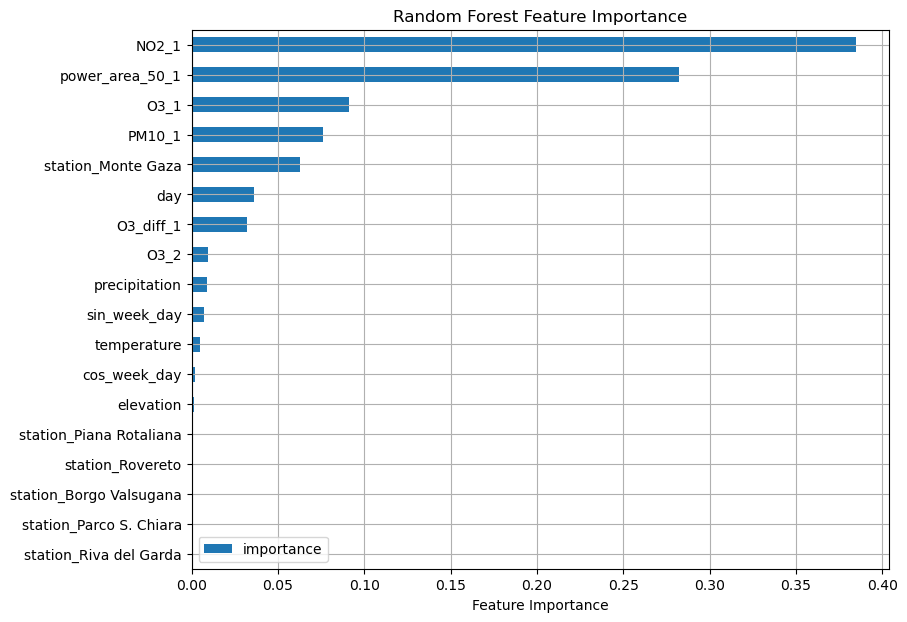

In [51]:
fs.display_importances(best_rfr_O3_d, feature_cols)

Come prima, le feature più rilevanti non sono quelle più legate da un punto di vista logico e fisico al target.

### Valutazione performance

In [52]:
full_O3_d_tr = O3_d_X_train.copy()
full_O3_d_tr['actual'] = O3_d_y_train
full_O3_d_tr['prediction'] = best_rfr_O3_d.predict(O3_d_X_train)

full_O3_d_te = O3_d_X_test.copy()
full_O3_d_te['actual'] = O3_d_y_test
full_O3_d_te['prediction'] = best_rfr_O3_d.predict(O3_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_O3_d_tr['actual'], full_O3_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_O3_d_te['actual'], full_O3_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          67.9659889621498
Root Mean Squared Error (RMSE):    8.244148771228586
Mean Absolute Error (MAE):         5.747327983334112
Coefficient of Determination (R2): 0.9105088637105186
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          150.9616205436526
Root Mean Squared Error (RMSE):    12.286643990270598
Mean Absolute Error (MAE):         10.191905435067309
Coefficient of Determination (R2): 0.807899085265467


Come sempre, si assiste ad una seria dimunuizione delle prestazioni del modello quando si interfaccia con dati nuovi ma non è un vero e proprio crollo come avvenuto per i PM2.5. Il modello sembra in realtà piuttosto buono, per quanto peggiore rispetto al modello orario (come sempre). Valutiamo qualitativamente le prestazioni del modello usando i grafici.

### Grafici previsioni

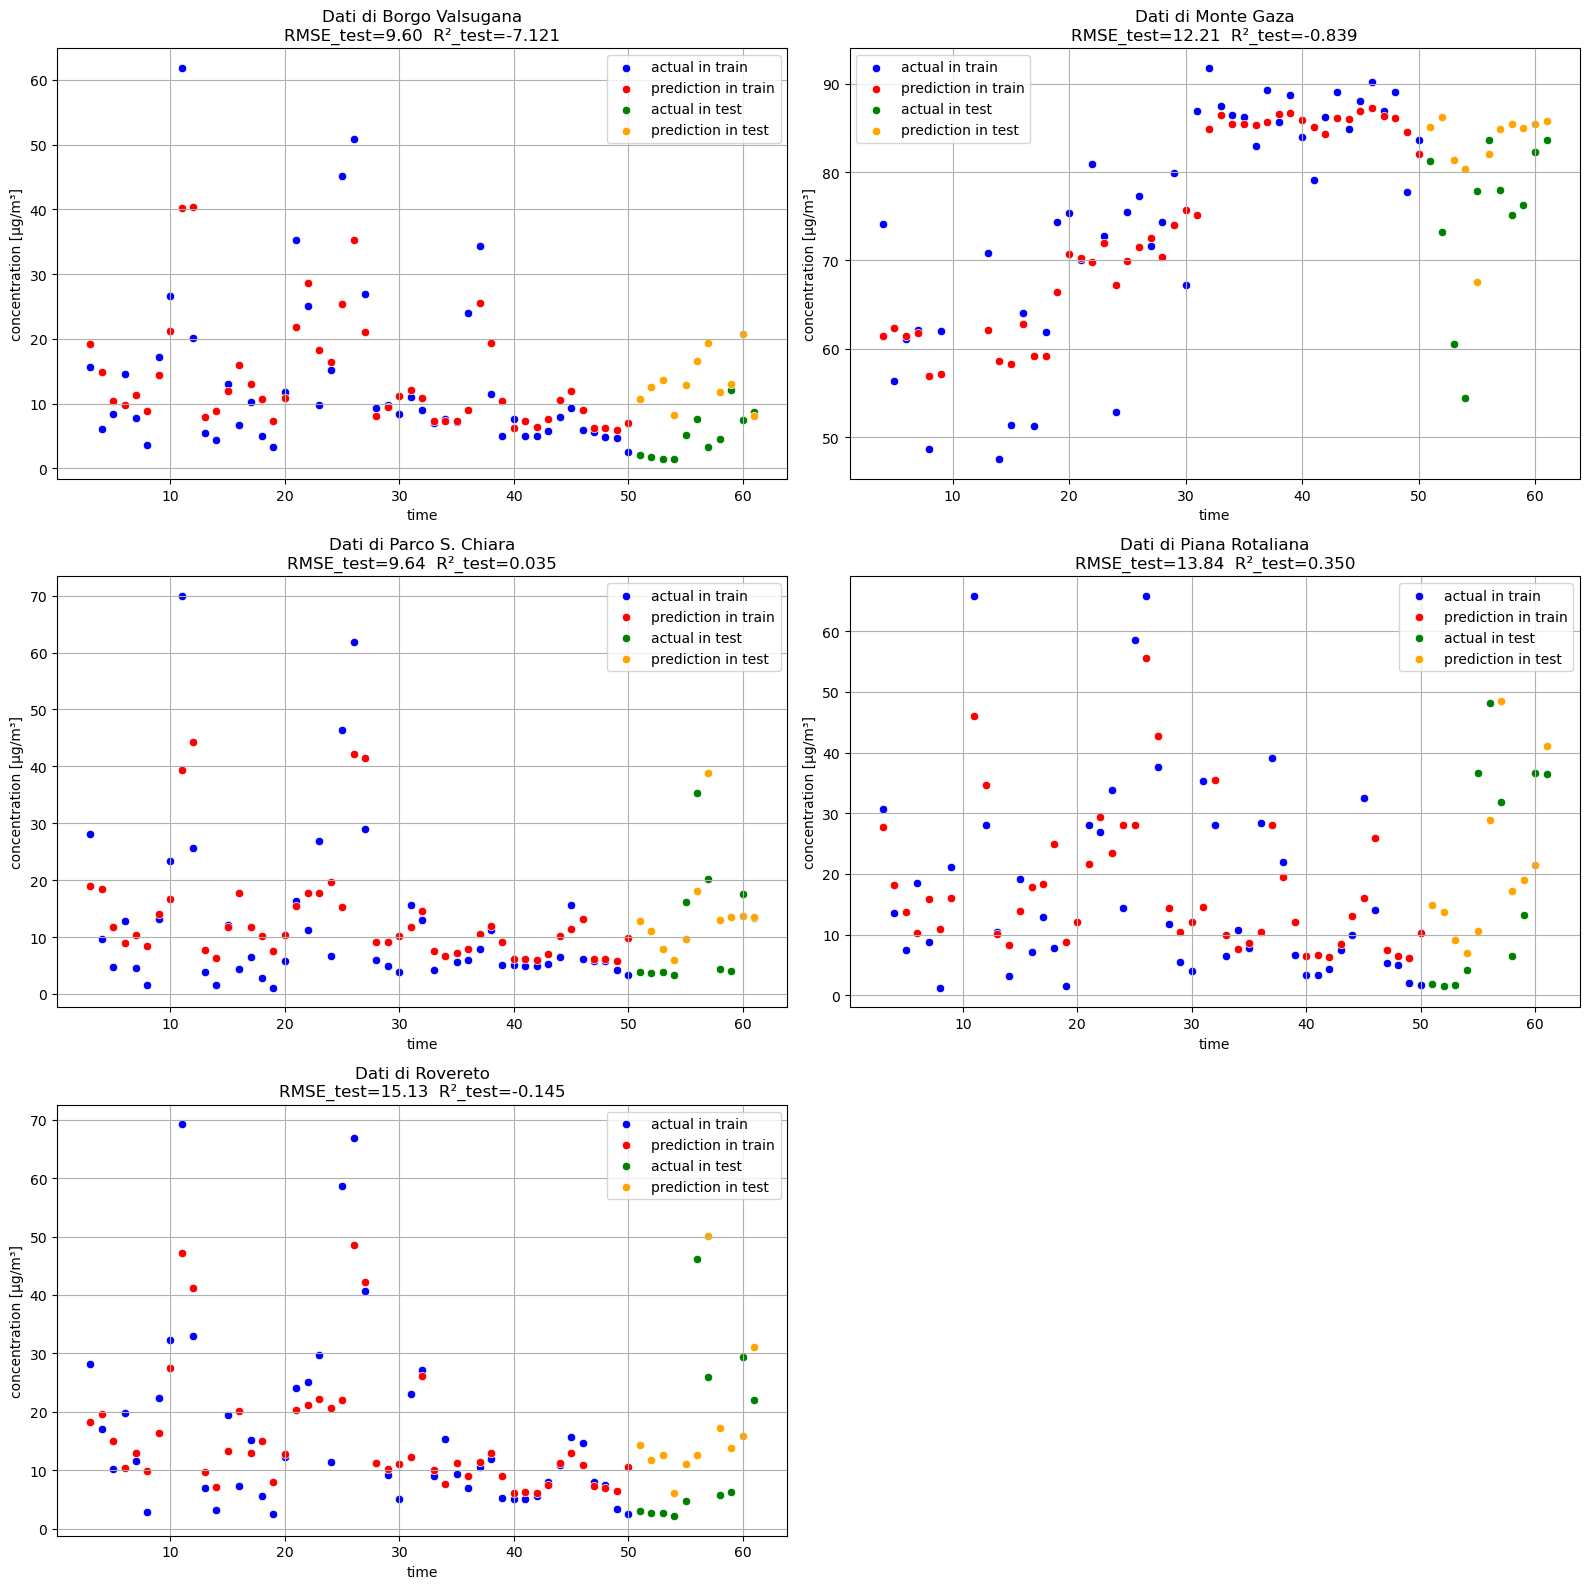

In [53]:
fs.plot_prediction_points(best_rfr_O3_d, O3_d_X_train, O3_d_y_train, O3_d_X_test, O3_d_y_test)

Le predizioni sono effettivamente più accurate rispetto a quanto avveniva pei PM10 e PM2.5. Tuttavia, questo sembra dovuto al fatto che il comportamento reale dell'ozono in test è meno patologico rispetto a quello di PM10 e PM2.5, e non tanto ad una effettiva bontà del modello. L'ozono, infatti, è sempre in controtendenza con gli altri inquinanti e, nel periodo in cui gli altri inquinanti mostrano un picco senza precedenti, l'ozono rimane costantemente basso ed è quindi difficile sbagliare le predizioni. Ad ogni modo, il modello sembra funzionare piuttosto bene e possiamo ritenerci soddisfatti.

# XGBoost - modelli giornalieri 2.0

Abbiamo visto che, nel caso di modelli a base giornaliera, i modelli costruiti con RandomForestRegressor lasciano un po' a desiderare. Proviamo quindi ad effettuare la regressione con metodo XGBoost, sperando di migliorare i risultati poco soddisfacenti di RandomForestRegressor.\
 Mentre RandomForestRegressor costruisce una foresta di alberi volutamente indipendenti e scorrelati tra loro e media le loro predizioni, XGBoost crea una serie di alberi in cui ognuno cerca di correggere gli errori del precedente. Mentre RandomForestRegressor cerca di costruire alberi profondi e ramificati che funzionano bene anche individualmente, XGBoost crea alberi più semplici, che sono predittori singolarmente più deboli ma che funzionano bene come ensemble.

## PM10

In [54]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM10_df = pd.read_csv('../../data/processed/dataset_day_PM10_processed.csv')

### Modello

In questo caso, dato l'ingente numero di iperparametri considerati da XGBoost, controllare tutte le combinazioni richiederebbe molte ore, Per questo motivo, implementiamo una strategia del tipo RandomizedSearchCV, in modo da non cercare la combinazione migliore in assoluto ma otterne una comunque molto buona. Usando RandomizedSearchCV, possiamo introdurre un ulteriore miglioramento: usare distribuzioni continue di parametri invece di valori discreti arbitrari.

In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

# distribuzioni degli iperparametri
param_dist = {'n_estimators': randint(150, 401),
                'max_depth': randint(2, 6),
                'learning_rate': uniform(0.02, 0.05),   # range effettivo 0.02-0.07
                'min_child_weight': randint(5, 21),
                'gamma': uniform(0.0, 1.0),
                'subsample': uniform(0.6, 0.2),         # range effettivo 0.6-0.8
                'colsample_bytree': uniform(0.6, 0.2),  # range effettivo 0.6-0.8
                'reg_alpha': uniform(0.1, 2.0),
                'reg_lambda': uniform(5.0, 20.0)}

# ricerca randomizzata degli iperparametri
XGB_PM10_d = RandomizedSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1),
                                param_distributions=param_dist,
                                n_iter=50,                              # prova 50 combinazioni casuali
                                scoring='neg_root_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                random_state=seed,
                                refit=True)

### Train, Test split

Dividiamo i dati in un insieme di training (80%) e uno di test (20%).

In [56]:
# splittiamo il dataset
feature_cols = day_PM10_df.columns.difference(['target'])

# creiamo train e test
PM10_d_X_train, _, PM10_d_X_test, PM10_d_y_train, _, PM10_d_y_test = fs.get_train_valid_test(day_PM10_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [57]:
# training
XGB_PM10_d.fit(PM10_d_X_train, PM10_d_y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x17a9b07d0>, 'gamma': <scipy.stats....t 0x1799936b0>, 'learning_rate': <scipy.stats....t 0x179b4abd0>, 'max_depth': <scipy.stats....t 0x179990fb0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :

In [58]:
print('Best score:')
print(XGB_PM10_d.best_score_)
# miglior modello
best_XGB_PM10_d = XGB_PM10_d.best_estimator_

Best score:
-10.314221348050289


### Valutazione performance

In [59]:
full_PM10_d_tr = PM10_d_X_train.copy()
full_PM10_d_tr['actual'] = PM10_d_y_train
full_PM10_d_tr['prediction'] = best_XGB_PM10_d.predict(PM10_d_X_train)

full_PM10_d_te = PM10_d_X_test.copy()
full_PM10_d_te['actual'] = PM10_d_y_test
full_PM10_d_te['prediction'] = best_XGB_PM10_d.predict(PM10_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM10_d_tr['actual'], full_PM10_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM10_d_te['actual'], full_PM10_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          21.043014095626447
Root Mean Squared Error (RMSE):    4.587266516742454
Mean Absolute Error (MAE):         3.4039858703188433
Coefficient of Determination (R2): 0.9080910486212416
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          198.12242494310755
Root Mean Squared Error (RMSE):    14.07559678816879
Mean Absolute Error (MAE):         10.368607452301811
Coefficient of Determination (R2): 0.5764489140633914


Il modello sembra effettivamente migliore rispetto a prima. Rimane presente un drammatico peggioramento delle prestazioni del modello ma non riteniamo che questo sia principalmente dovuto all'overfitting poiché il valore dell'RMSE in test (14.1) è relativamente simile all'RMSE minimo ottenuto durante il RandomSearchCV (10.3). Quindi, anche tenendo conto di questo calo (che come visto è inevitabile poiché direttamente causato dai dati), il modello mostra prestazioni perlomeno decenti e, in ogni caso, migliori rispetto a prima.

### Grafici previsioni

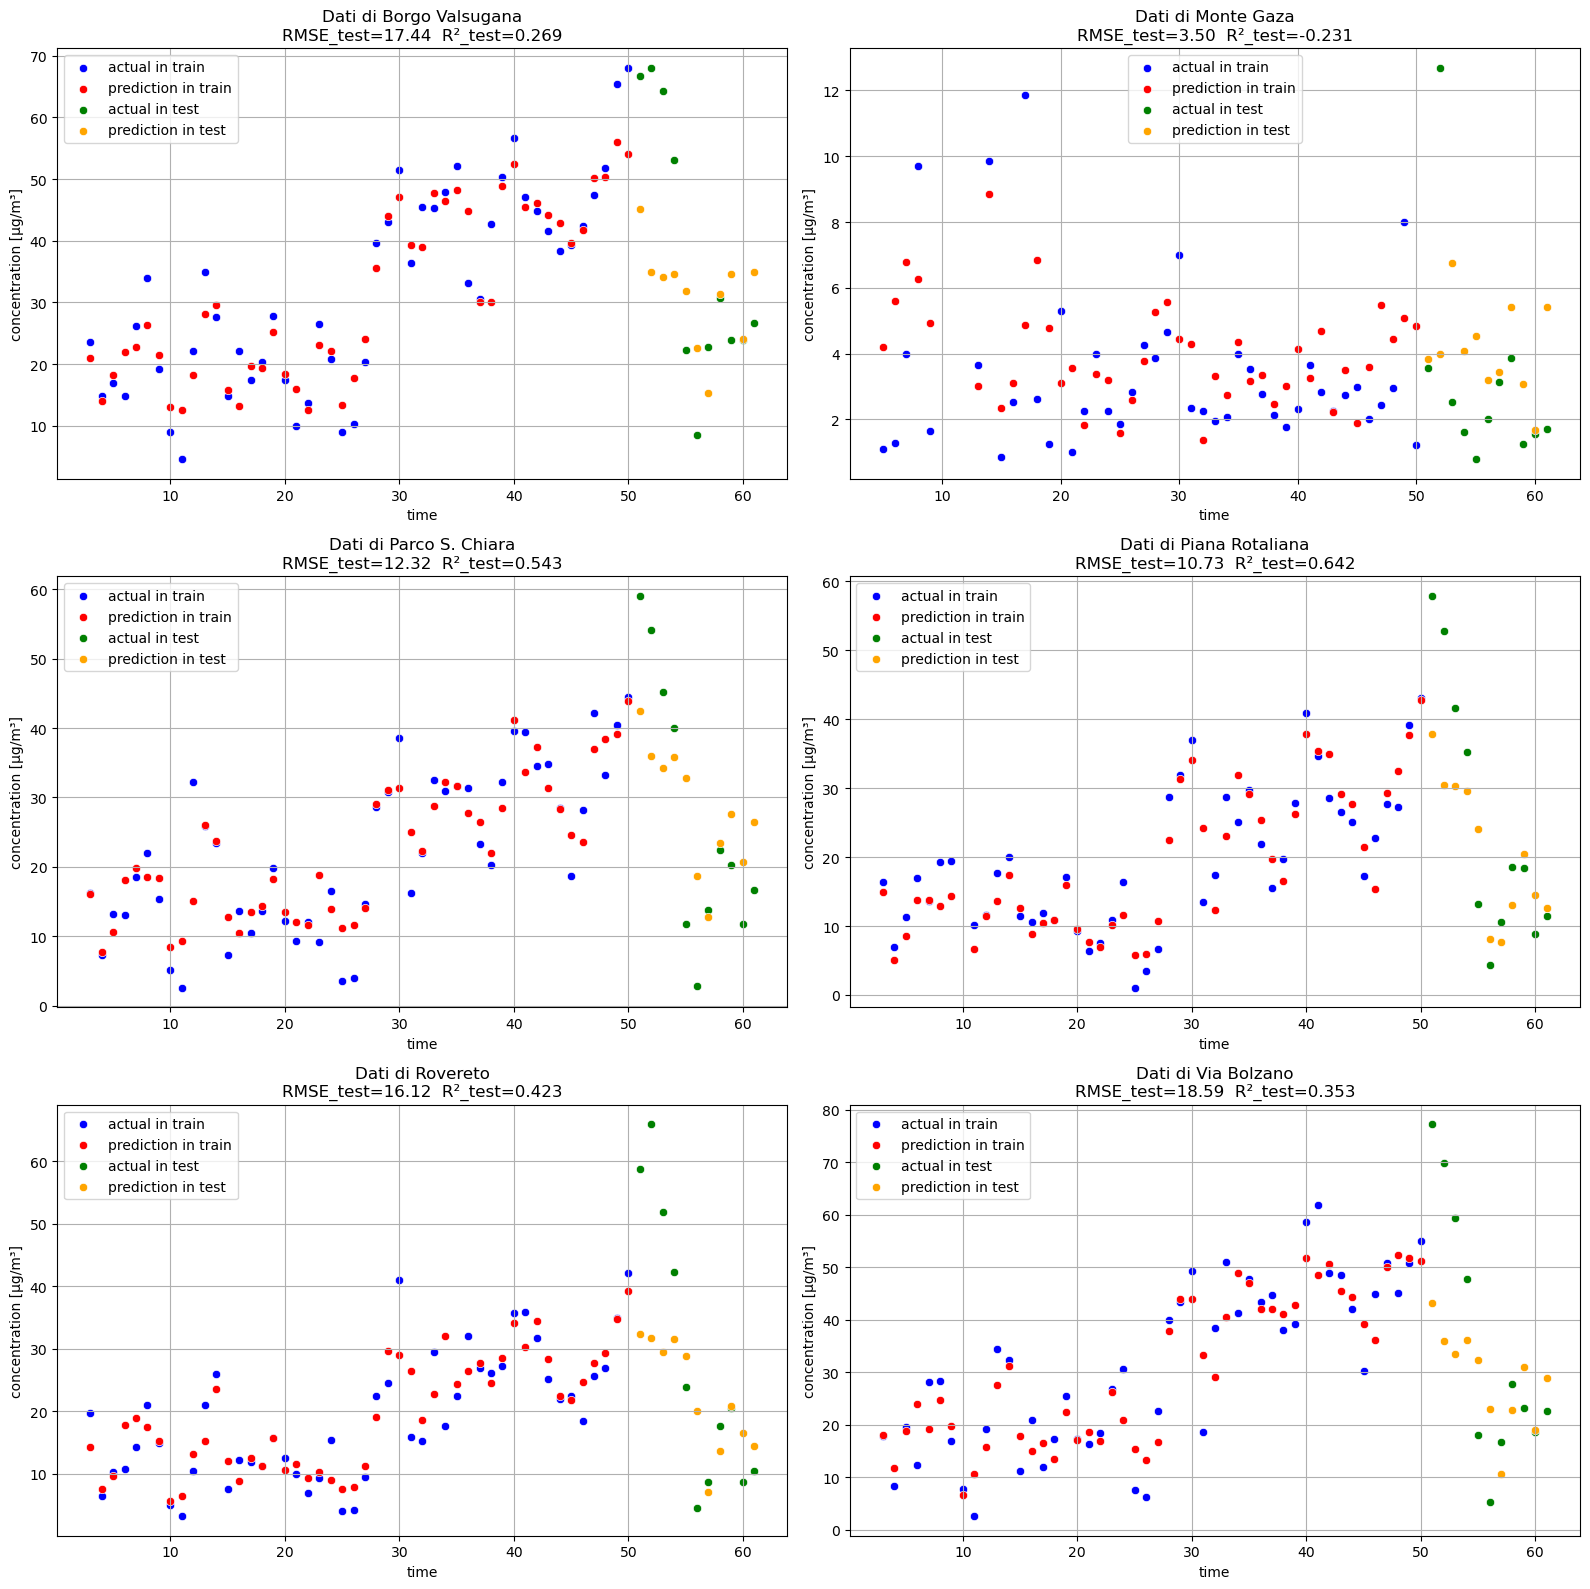

In [60]:
fs.plot_prediction_points(best_XGB_PM10_d, PM10_d_X_train, PM10_d_y_train, PM10_d_X_test, PM10_d_y_test)

Vediamo che in train il modello funziona con buona accuratezza, tuttavia, su test peggiora significativamente, soprattutto in corrispondenza del picco, dove si interfaccia con dati molto diversi da quelli su cui è stato allenato.

## PM2.5

In [61]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_PM25_df = pd.read_csv('../../data/processed/dataset_day_PM2_5_processed.csv')

### Modello

In [62]:
# ricerca randomizzata degli iperparametri
XGB_PM25_d = RandomizedSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1),
                                param_distributions=param_dist,
                                n_iter=50,                              # prova 50 combinazioni casuali
                                scoring='neg_root_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                random_state=seed,
                                refit=True)

### Train, Test split

In [63]:
# splittiamo il dataset
feature_cols = day_PM25_df.columns.difference(['target'])

# creiamo train e test
PM25_d_X_train, _, PM25_d_X_test, PM25_d_y_train, _, PM25_d_y_test = fs.get_train_valid_test(day_PM25_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [64]:
# training
XGB_PM25_d.fit(PM25_d_X_train, PM25_d_y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x17a9b07d0>, 'gamma': <scipy.stats....t 0x1799936b0>, 'learning_rate': <scipy.stats....t 0x179b4abd0>, 'max_depth': <scipy.stats....t 0x179990fb0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :

In [65]:
print('Best score:')
print(XGB_PM25_d.best_score_)
# miglior modello
best_XGB_PM25_d = XGB_PM25_d.best_estimator_

Best score:
-7.338403050455659


### Valutazione performance

In [66]:
full_PM25_d_tr = PM25_d_X_train.copy()
full_PM25_d_tr['actual'] = PM25_d_y_train
full_PM25_d_tr['prediction'] = best_XGB_PM25_d.predict(PM25_d_X_train)

full_PM25_d_te = PM25_d_X_test.copy()
full_PM25_d_te['actual'] = PM25_d_y_test
full_PM25_d_te['prediction'] = best_XGB_PM25_d.predict(PM25_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_PM25_d_tr['actual'], full_PM25_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_PM25_d_te['actual'], full_PM25_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          3.501864314481985
Root Mean Squared Error (RMSE):    1.871326886057587
Mean Absolute Error (MAE):         1.3918656937130647
Coefficient of Determination (R2): 0.961555906014967
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          192.1216716762426
Root Mean Squared Error (RMSE):    13.860796213646697
Mean Absolute Error (MAE):         11.774727459368773
Coefficient of Determination (R2): 0.26726529220524864


Vediamo che, purtroppo, anche usando XGBoost il modello migliora solo marginalmente rispetto a RandomForestRegressor. Sarebbe interessante riprovare questo esercizio a partire da un dataset molto più esteso (magari svariati anni) in modo da allenare meglio il modello e magari avere meno differenze tra train e test.

### Grafici previsioni

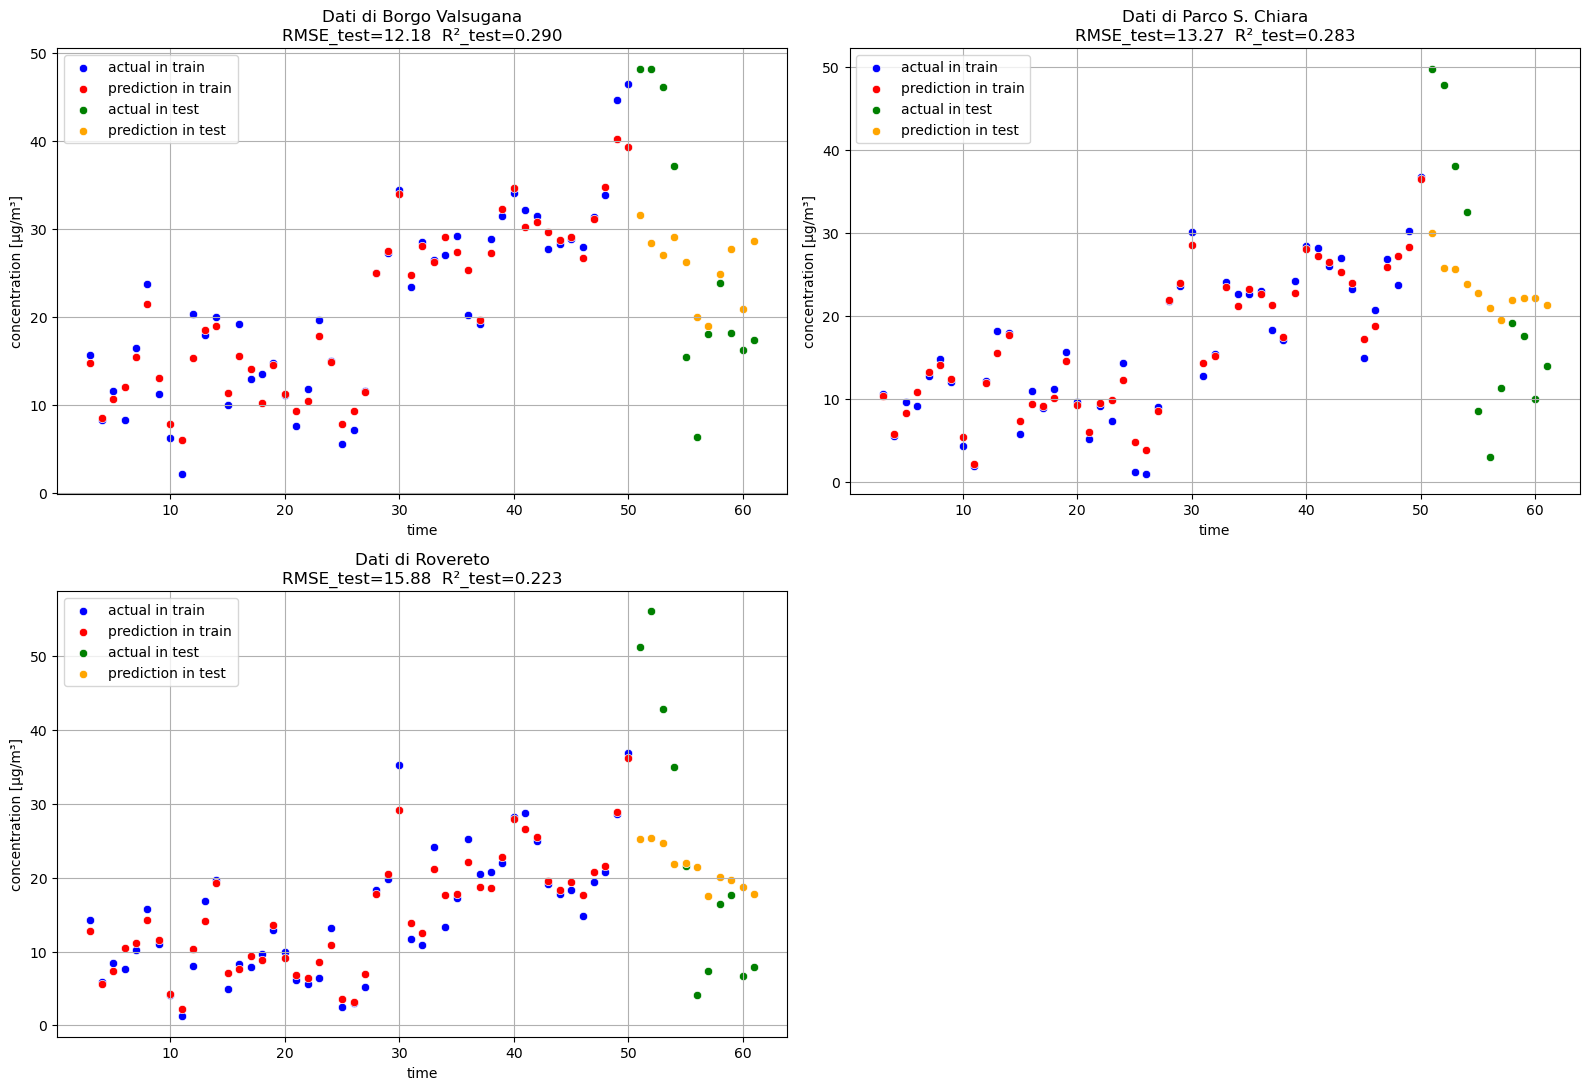

In [67]:
fs.plot_prediction_points(best_XGB_PM25_d, PM25_d_X_train, PM25_d_y_train, PM25_d_X_test, PM25_d_y_test)

Vediamo che mentre in train il modello funziona molto molto bene, in test perde completamente la sua validità.

## O3

In [68]:
# importiamo il dataframe creato precedentemente appositamente per questo studio
day_O3_df = pd.read_csv('../../data/processed/dataset_day_O3_processed.csv')

### Modello

In [69]:
# ricerca randomizzata degli iperparametri
XGB_O3_d = RandomizedSearchCV(estimator=XGBRegressor(objective='reg:squarederror', random_state=seed, n_jobs=-1),
                                param_distributions=param_dist,
                                n_iter=50,                              # prova 50 combinazioni casuali
                                scoring='neg_root_mean_squared_error',
                                cv=tscv,
                                n_jobs=-1,
                                random_state=seed,
                                refit=True)

### Train, Test split

In [70]:
# splittiamo il dataset
feature_cols = day_O3_df.columns.difference(['target'])

# creiamo train e test
O3_d_X_train, _, O3_d_X_test, O3_d_y_train, _, O3_d_y_test = fs.get_train_valid_test(day_O3_df, 0.8, 0.0, feature_cols)

### Allenamento modello

In [71]:
# training
XGB_O3_d.fit(O3_d_X_train, O3_d_y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x17a9b07d0>, 'gamma': <scipy.stats....t 0x1799936b0>, 'learning_rate': <scipy.stats....t 0x179b4abd0>, 'max_depth': <scipy.stats....t 0x179990fb0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :

In [72]:
print('Best score:')
print(XGB_O3_d.best_score_)
# miglior modello
best_XGB_O3_d = XGB_O3_d.best_estimator_

Best score:
-18.26979946609986


### Valutazione performance

In [73]:
full_O3_d_tr = O3_d_X_train.copy()
full_O3_d_tr['actual'] = O3_d_y_train
full_O3_d_tr['prediction'] = best_XGB_O3_d.predict(O3_d_X_train)

full_O3_d_te = O3_d_X_test.copy()
full_O3_d_te['actual'] = O3_d_y_test
full_O3_d_te['prediction'] = best_XGB_O3_d.predict(O3_d_X_test)

print('Performance su train')
mse_tr, rmse_tr, mae_tr, r2_tr = fs.evaluation(full_O3_d_tr['actual'], full_O3_d_tr['prediction'])
print('-----------------------------------------------------')
print('Performance su test')
mse_te, rmse_te, mae_te, r2_te = fs.evaluation(full_O3_d_te['actual'], full_O3_d_te['prediction'])

Performance su train
Mean Squared Error (MSE):          10.898257291646374
Root Mean Squared Error (RMSE):    3.3012508677236836
Mean Absolute Error (MAE):         2.421198881596632
Coefficient of Determination (R2): 0.9856502135333056
-----------------------------------------------------
Performance su test
Mean Squared Error (MSE):          149.6563114787623
Root Mean Squared Error (RMSE):    12.233409642399877
Mean Absolute Error (MAE):         10.307864262221695
Coefficient of Determination (R2): 0.8095601105278728


Vediamo che il modello rimane in realtà effettivamente invariato rispetto a quanto ottenuto con RandomForestRegressor.

### Grafici previsioni

In [74]:
# aggiungiamo il tempo
full_O3_d_tr['time'] = full_O3_d_tr['day']
full_O3_d_te['time'] = full_O3_d_te['day']

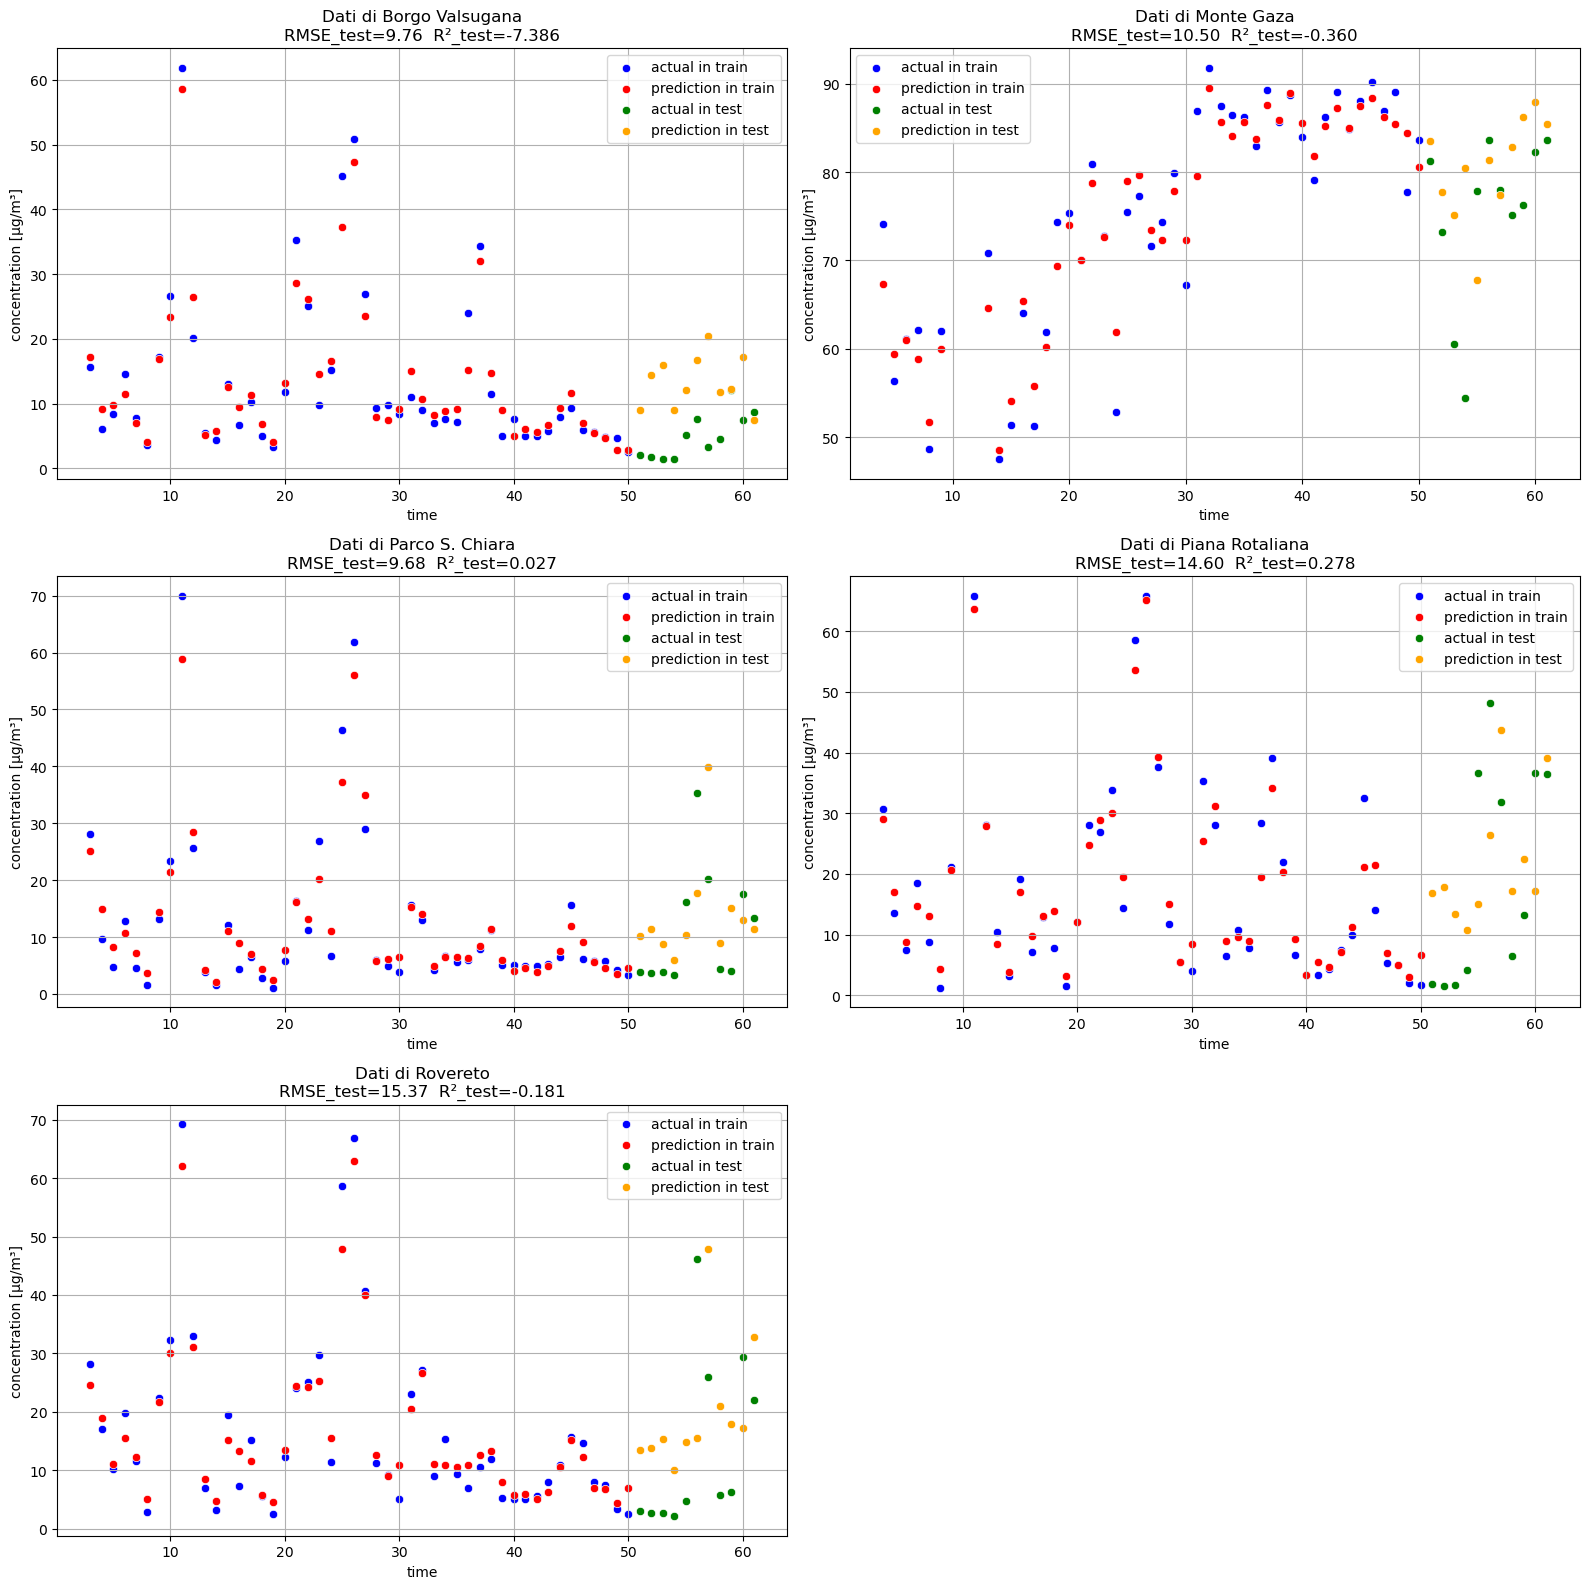

In [75]:
fs.plot_prediction_points(best_XGB_O3_d, O3_d_X_train, O3_d_y_train, O3_d_X_test, O3_d_y_test)

Vediamo che il modello è molto poco accurato in test e il buon valore dei parametri è dovuto più al fatto che i dati di test sono molto omogenei che all'effettiva qualità del modello.

# Conclusioni

Riteniamo l'allenamento dei modelli orari un successo visto che i modelli si comportano piuttosto bene su test e producono predizioni ragionevolmente vicine alla realtà. D'altro canto, i modelli giornalieri sono poco efficaci e, a causa della carenza di dati, non siamo in grado di risolvere le patologie dei nostri insiemi.